<a href="https://colab.research.google.com/github/NamGaik/DL_Astronomy/blob/main/Research_Paper_DLAstro_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PHASE A- Data Preperation**

astroNN- function to download Galay10 ds

timm- Open source Python library containing pre-trained models

torchmetrics- Ready-made formulas for accuracy, ECE

grad-cam- Code to generate heatmap visualisations

zoobot- pretrained galaxy foundation model

In [ ]:
#Step 1: Download Packages
!pip install astroNN timm torchmetrics grad-cam scikit-learn matplotlib seaborn -q
!pip install "zoobot[pytorch]" -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 36.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.3/75.3 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 87.6 MB/s eta 0:00:00

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Step 2: Import Packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchmetrics.classification import MulticlassCalibrationError
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score,
                             precision_score, recall_score,
                             confusion_matrix)
import timm
import gc
import warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

NUM_CLASSES = 10
CLASS_NAMES = [
    "Disturbed", "Merging", "Round Smooth",
    "In-between Smooth", "Cigar Smooth", "Barred Spiral",
    "Unbarred Tight Spiral", "Unbarred Loose Spiral",
    "Edge-on without Bulge", "Edge-on with Bulge"
]

Device: cuda


torch- the core PyTorch library, handles tensors and GPU computation

torch.nn-  building blocks for neural networks (layers, loss functions)

torch.optim- optimizers (the algorithms that update model weights during training, like AdamW)

torch.optim.lr- a  tool that gradually decreases the learning rate as training progresses. You'll use this when training each model.

torchvision- Tools for resizing, flipping, rotating, and normalizing images before feeding them to the model.

torchmetrics.classification- calculates ECE (Expected Calibration Error) — the number that tells you if your model's confidence is trustworthy

import timm- Gives you access to ResNet-50, ViT, and other pretrained models with one line of code each.

**Setting a seed forces all that "randomness" to follow the same fixed sequence every time. So if you run your notebook today and again next week, you get the exact same split, same training behavior, same numbers.


**defining classes- Galaxy10 has 10 categories. This number gets used later when building your models — it tells the model "your final output layer should have 10 numbers, one probability per class."

NUM_CLASSES = 10 is used when building model heads — tells the final layer how many outputs to produce. CLASS_NAMES maps integer labels (0-9) to human readable names for charts and printouts. Position matters — index 0 must match label 0 from the dataset.

0-Disturbed:- A galaxy whose shape looks irregular, asymmetric, or messed up — not a clean smooth blob or organized spiral.

1-Merging:- Two or more galaxies taht are actively colliding or fusing together.  Unlike "Disturbed" (one distorted galaxy), here you can often visually make out multiple distinct cores or bodies tangled together — like two blobs of light bridging into each other.

2-Round Smooth:- A galay that's circular and has no visible internal structure- no spiral arms, no dust lanes, just a smooth, even glow that fades out from the center.

3-In-between Smooth:- Also smooth (no spiral arms or structure) but not perfectly round — more oval or elongated in shape. This is an elliptical galaxy that's somewhat flattened, sitting between "perfectly round" and "very elongated cigar-shaped."

4-Cigar Smooth:- Smooth galaxy (still no arms or structure) but very elongated and narrow, like a cigar or rugby ball shape.

**The progression from class 2 → 3 → 4 is actually a spectrum: round → slightly elongated → very elongated. All three are smooth ellipticals, just differing in how flattened they appear.

5- Barred Spiral:- A spiral galaxy that has a straight bar-shaped structure of stars cutting through its center, with spiral arms unwinding from the ends of that bar rather than directly from the nucleus.

6- Unbarred Tight Spiral:- A spiral galaxy with no central bar, where the spiral arms are wound tightly — they curl closely around the center, making many close loops rather than spreading out widely.

7- Unbarred Loose Spiral:- no central bar — but the spiral arms are wound loosely, spreading out wide and open rather than curling tightly.

8- Edge-on without Bulge:- A spiral or disc galaxy that we happen to be viewing exactly from the side, so it looks like a thin flat line or streak of light, rather than seeing its spiral structure from above. "Without bulge" means there's no obvious bright, puffy central swelling — the disc looks roughly the same brightness/thickness along its whole length.

9- Edge-on with Bulge:- Same edge-on viewing angle (a thin streak), but this time there IS a noticeable bright, rounded bulge swelling out at the center.

**Metrics Used:-**

accuracy_score — percentage of correct predictions

f1_score — harmonic mean of precision and recall, better for imbalanced classes

precision_score — of all predictions for class X, how many were actually X

recall_score — of all actual class X images, how many did the model find

confusion_matrix — 10×10 grid showing where the model made mistakes

**import timm-** PyTorch Image Models library. One line gives you any architecture — timm.create_model('resnet50', pretrained=True) loads a full ResNet-50 with ImageNet weights.

**import gc-** Python's garbage collector. You use this to force immediate memory cleanup after deleting large arrays. Without it, Python might not free RAM fast enough, causing crashes.

In [ ]:
#Step 3: Load Galaxy10 DECaLS
from astroNN.datasets import load_galaxy10
images, labels = load_galaxy10()
print(f"Images : {images.shape}")
print(f"Labels : {labels.shape}")
print(f"Classes: {np.unique(labels)}")

Galaxy10_DECals.h5: 100%|█████████▉| 2.73G/2.74G [00:56<00:00, 48.1MB/s]

Downloaded Galaxy10 successfully to /root/.astroNN/datasets/Galaxy10_DECals.h5


Galaxy10_DECals.h5: 2.74GB [01:16, 35.6MB/s]                            


Images : (17736, 256, 256, 3)
Labels : (17736,)
Classes: [0 1 2 3 4 5 6 7 8 9]


**load_galaxy10()** connects to the internet, downloads Galaxy10 DECaLS (~200MB), and returns two NumPy arrays. On subsequent runs it uses the cached file.

    images — shape (17736, 256, 256, 3):

17736 = number of galaxy images
256 = height in pixels
256 = width in pixels
3 = color channels (Red, Green, Blue)

    labels — shape (17736,):

17736 integers, each between 0 and 9
Position matches images exactly — labels[i] is the class of images[i]

**Sanity check**- np.unique(labels) returns every distinct value found in labels without repeats. Should print [0 1 2 3 4 5 6 7 8 9] confirming 10 classes with no gaps.

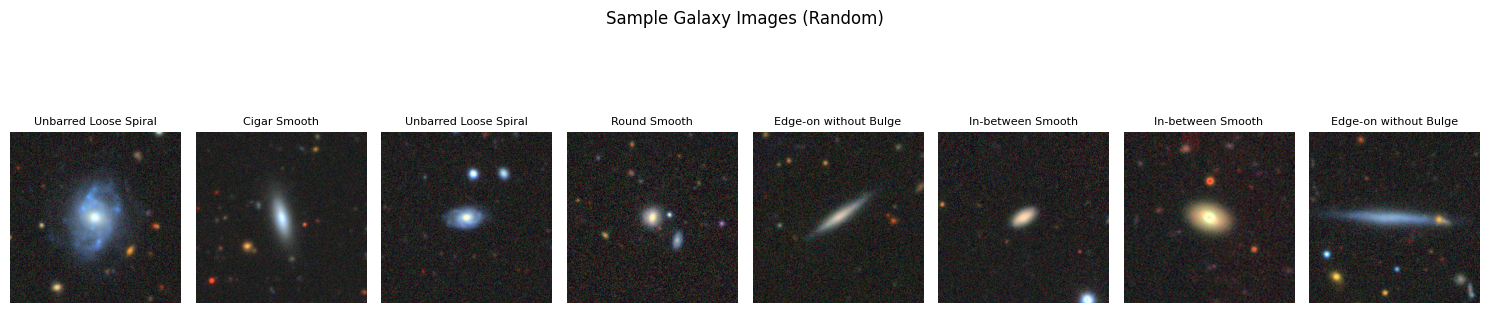

Sample images displayed.
File saved: sample_images.png


In [ ]:
#Step 4: Visualise sample images
# Sanity check — confirm images and labels are correctly paired
# Picks random images so you see variety across classes

# Pick 8 random images instead of first 8 in order
# (first 8 are all "Disturbed" since data is grouped by class)
np.random.seed(SEED)
random_indices = np.random.choice(len(images), size=8, replace=False)

plt.figure(figsize=(15, 4))
for plot_pos, idx in enumerate(random_indices):
    plt.subplot(1, 8, plot_pos + 1)
    plt.imshow(images[idx])
    plt.title(CLASS_NAMES[labels[idx]], fontsize=8)
    plt.axis('off')

plt.suptitle("Sample Galaxy Images (Random)")
plt.tight_layout()
plt.savefig("sample_images.png", dpi=120)
plt.show()

print("Sample images displayed.")
print("File saved: sample_images.png")

There are really three big physical groups hiding in this list of 10:

SMOOTH / ELLIPTICAL galaxies (no arms, just a glow)
  → Round Smooth, In-between Smooth, Cigar Smooth
    (differ only by how elongated they look)

SPIRAL galaxies (seen face-on or at an angle, arms visible)
  → Barred Spiral, Unbarred Tight Spiral, Unbarred Loose Spiral
    (differ by presence of a bar, and how tightly the arms wind)

SPIRAL/DISC galaxies seen EDGE-ON (so arms aren't visible, just a thin streak)
  → Edge-on without Bulge, Edge-on with Bulge
    (differ by whether there's a central bulge)

IRREGULAR / INTERACTING galaxies (not fitting the clean categories above)
  → Disturbed, Merging
    (differ by whether it's one messed-up galaxy or multiple colliding)

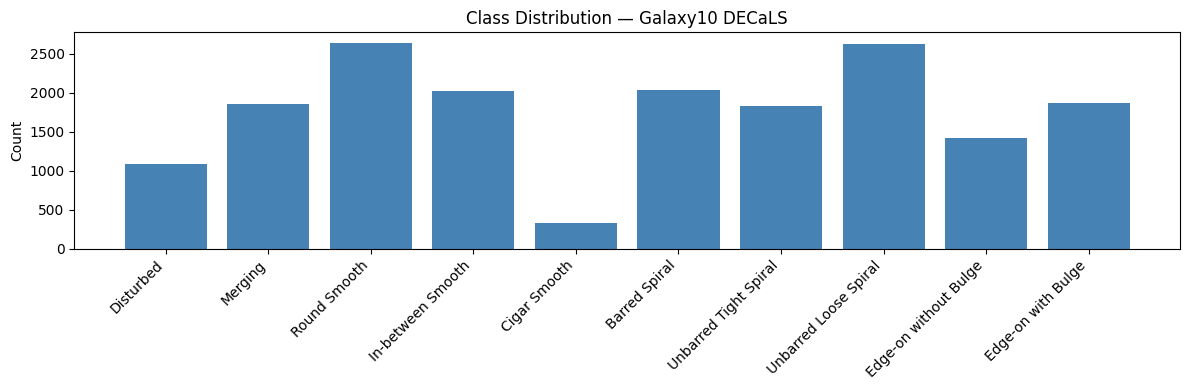

Class counts:
----------------------------------------
  Disturbed                     : 1081
  Merging                       : 1853
  Round Smooth                  : 2645
  In-between Smooth             : 2027
  Cigar Smooth                  : 334
  Barred Spiral                 : 2043
  Unbarred Tight Spiral         : 1829
  Unbarred Loose Spiral         : 2628
  Edge-on without Bulge         : 1423
  Edge-on with Bulge            : 1873
----------------------------------------
  Total                         : 17736

Most common class : Round Smooth (2645)
Rarest class      : Cigar Smooth (334)

File saved: class_distribution.png


In [ ]:
#Step 5: Class Distribution Chart

# Records class imbalance — important for results discussion

# Count how many images belong to each class
unique, counts = np.unique(labels, return_counts=True)

#Bar Chart
plt.figure(figsize=(12, 4))
plt.bar([CLASS_NAMES[i] for i in unique], counts, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title("Class Distribution — Galaxy10 DECaLS")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=120)
plt.show()

#Print exact counts
print("Class counts:")
print("-" * 40)
for i, c in zip(unique, counts):
    print(f"  {CLASS_NAMES[i]:<30}: {c}")
print("-" * 40)
print(f"  {'Total':<30}: {counts.sum()}")
print(f"\nMost common class : {CLASS_NAMES[unique[counts.argmax()]]} ({counts.max()})")
print(f"Rarest class      : {CLASS_NAMES[unique[counts.argmin()]]} ({counts.min()})")
print("\nFile saved: class_distribution.png")

By this we understand there is class imbalance in the dataset. Some galaxy types are naturally rarer in nature (mergers, disturbed galaxies) than others (smooth round galaxies, spirals) and by the numbers we can confirm it and also understand that which classes have less training data- which matters because models tend to perform worse on classes they see less often.

This matters for your project because it explains why certain classes get confused with each other in your eventual confusion matrix. For example:

**Round Smooth vs In-between Smooth vs Cigar Smooth** are genuinely on a continuous spectrum of elongation — a model is naturally going to struggle distinguishing borderline cases between these three, since the difference is just "how stretched is it," not a sharp categorical boundary.

**Unbarred Tight Spiral vs Unbarred Loose Spiral** is similarly a spectrum (how tightly wound), not a hard line.

**Disturbed vs Merging** can overlap too — a merging pair might just look like one disturbed blob if the two galaxies are close enough together or the image resolution is too low to separate them.

In [ ]:
#Step 6: Train/Val/Test Split

# Split data into 70% train, 15% val, 15% test
# using indices instead of full image arrays to avoid RAM crash

# Create an array of indices [0, 1, 2, ..., 17735]
# instead of copying the actual image data
all_indices = np.arange(len(images))
labels_np   = labels.copy()

# First split: carve out 15% for the test set
# stratify=labels ensures each split has same class proportions
idx_temp, idx_test = train_test_split(
    all_indices,
    test_size=0.15,
    random_state=SEED,
    stratify=labels_np
)

# Second split: divide remaining 85% into train (70%) and val (15%)
# 0.1765 = 15/85, so that val ends up as ~15% of total dataset
idx_train, idx_val = train_test_split(
    idx_temp,
    test_size=0.1765,
    random_state=SEED,
    stratify=labels_np[idx_temp]
)

print(f"Train : {len(idx_train)} images")
print(f"Val   : {len(idx_val)} images")
print(f"Test  : {len(idx_test)} images")
print(f"Total : {len(idx_train)+len(idx_val)+len(idx_test)}")

# Save indices to disk so split is preserved if session disconnects
np.save('idx_train.npy', idx_train)
np.save('idx_val.npy',   idx_val)
np.save('idx_test.npy',  idx_test)
np.save('labels.npy',    labels_np)
print("Indices saved.")

Train : 12414 images
Val   : 2661 images
Test  : 2661 images
Total : 17736
Indices saved.


In [ ]:
#Step 7: Dataset class and dataloaders

# Wraps images + indices into a PyTorch Dataset
# Converts float32 one image at a time (memory efficient)
# DataLoaders feed images to model in batches during training


class GalaxyDataset(Dataset):
    def __init__(self, images, indices, labels, transform=None):
        # images  = full original array (stays as uint8, never copied)
        # indices = positions belonging to this split (train/val/test)
        # labels  = class number for each image
        self.images    = images
        self.indices   = indices
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        # tells PyTorch how many images are in this split
        return len(self.indices)

    def __getitem__(self, i):
        # called once per image when DataLoader requests a batch
        idx = self.indices[i]

        # convert to float32 here, one image at a time
        # never converts all 17736 images at once
        img = self.images[idx].astype(np.float32) / 255.0

        # reshape from (H, W, C) to (C, H, W) — PyTorch format
        img = torch.tensor(img).permute(2, 0, 1)

        if self.transform:
            img = self.transform(img)

        return img, int(self.labels[idx])


# Training transforms: augmentation makes the model more robust
# Rotation 360 degrees is physically valid — galaxies have no fixed orientation
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),          # resize to match pretrained model input
    transforms.RandomHorizontalFlip(),      # random mirror
    transforms.RandomVerticalFlip(),        # random flip
    transforms.RandomRotation(360),         # full rotation (galaxy symmetry)
    transforms.ColorJitter(brightness=0.2,
                           contrast=0.2),   # slight brightness/contrast variation
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])  # ImageNet normalization
])

# Evaluation transforms: no augmentation, just resize + normalize
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Create one dataset object per split, each pointing to different indices
train_ds = GalaxyDataset(images, idx_train, labels_np, train_transform)
val_ds   = GalaxyDataset(images, idx_val,   labels_np, eval_transform)
test_ds  = GalaxyDataset(images, idx_test,  labels_np, eval_transform)

# DataLoaders: feed images to model in batches of 32
# shuffle=True for train so model doesn't memorize the order
# shuffle=False for val/test so evaluation is consistent
train_loader = DataLoader(train_ds, batch_size=32,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32,
                          shuffle=False, num_workers=2, pin_memory=True)

print("DataLoaders ready.")
print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

DataLoaders ready.
Train batches : 388
Val batches   : 84
Test batches  : 84


Before: copied 17,736 images into RAM 5 times simultaneously as float32 arrays → crashed. After: stored only a list of 17,736 index numbers and converted images one at a time during training → no crash.

**PHASE B: Baseline Model**

In [ ]:
#Step 1: Define Training and Evaluation Functions

# These functions are used for ALL models — ResNet, ViT, Zoobot

def train_model(model, model_name, epochs=30, lr=1e-4):
    """
    Trains any model using the same settings.
    Saves best weights to disk during training.
    Returns the model and training history.
    """
    model = model.to(device)

    # AdamW optimizer — works well for both CNNs and Transformers
    optimizer = optim.AdamW(model.parameters(),
                            lr=lr, weight_decay=1e-4)

    # Gradually reduces learning rate as training progresses
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

    # Loss function — label_smoothing=0.1 prevents overconfidence
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    best_val_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):

        # ---- TRAINING PHASE ----
        model.train()
        t_loss = 0.0
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()          # clear old gradients
            loss = criterion(model(imgs), lbls)  # forward pass + loss
            loss.backward()                # backward pass
            optimizer.step()               # update weights
            t_loss += loss.item()
        scheduler.step()                   # update learning rate

        # ---- VALIDATION PHASE ----
        model.eval()
        correct, total, v_loss = 0, 0, 0.0
        with torch.no_grad():              # no gradient needed for val
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                out    = model(imgs)
                v_loss += criterion(out, lbls).item()
                correct += (out.argmax(1) == lbls).sum().item()
                total   += lbls.size(0)

        val_acc = correct / total

        # Record history for training curves
        history['train_loss'].append(t_loss / len(train_loader))
        history['val_loss'].append(v_loss  / len(val_loader))
        history['val_acc'].append(val_acc)

        # Save best model weights seen so far
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'best_{model_name}.pth')

        # Print progress every 5 epochs
        if (epoch + 1) % 5 == 0:
            print(f"[{model_name}] Ep {epoch+1}/{epochs} | "
                  f"TrainLoss {t_loss/len(train_loader):.4f} | "
                  f"ValAcc {val_acc:.4f}")

    print(f"\n[{model_name}] Best ValAcc: {best_val_acc:.4f}")
    return model, history


def evaluate_model(model, model_name, loader=None):
    """
    Evaluates a trained model on the test set.
    Returns metrics dict + probability tensor + true labels tensor.
    """
    if loader is None:
        loader = test_loader

    model.eval()
    all_preds, all_true, all_probs = [], [], []

    with torch.no_grad():
        for imgs, lbls in loader:
            out   = model(imgs.to(device))
            probs = torch.softmax(out, dim=1)  # convert to probabilities
            all_probs.append(probs.cpu())
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_true.extend(lbls.numpy())

    probs_t = torch.cat(all_probs)       # all probabilities stacked
    true_t  = torch.tensor(all_true)     # all true labels stacked

    # Calculate all metrics
    acc  = accuracy_score(all_true, all_preds)
    f1   = f1_score(all_true, all_preds, average='macro')
    prec = precision_score(all_true, all_preds,
                           average='macro', zero_division=0)
    rec  = recall_score(all_true, all_preds, average='macro')

    # ECE — calibration error (used in Phase E)
    ece_fn = MulticlassCalibrationError(num_classes=NUM_CLASSES, n_bins=15)
    ece    = ece_fn(probs_t, true_t).item()

    # Count model parameters
    params = sum(p.numel() for p in model.parameters()) / 1e6

    result = {
        'Model':     model_name,
        'Accuracy':  round(acc  * 100, 2),
        'Precision': round(prec * 100, 2),
        'Recall':    round(rec  * 100, 2),
        'F1-macro':  round(f1   * 100, 2),
        'ECE':       round(ece, 4),
        'Params(M)': round(params, 2)
    }
    print("\nTest Results:")
    print(result)
    return result, probs_t, true_t


def plot_training_curves(history, model_name):
    """
    Plots training loss and validation accuracy over epochs.
    Saves the figure as a PNG file.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Loss curves
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'],   label='Val Loss')
    ax1.set_title(f'{model_name} — Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # Validation accuracy curve
    ax2.plot(history['val_acc'], color='green', label='Val Accuracy')
    ax2.set_title(f'{model_name} — Validation Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.savefig(f'curves_{model_name}.png', dpi=120)
    plt.show()
    print(f"File saved: curves_{model_name}.png")


print("Training and evaluation functions defined.")
print("Ready to train models.")

Training and evaluation functions defined.
Ready to train models.


In [ ]:
# RELOAD CELL

from google.colab import drive
from astroNN.datasets import load_galaxy10
from zoobot.pytorch.estimators import define_model
import os

drive.mount('/content/drive')

#Load Data
images, labels = load_galaxy10()
print(f"Images: {images.shape}")

#Load Splits
if os.path.exists('/content/drive/MyDrive/idx_train.npy'):
    idx_train = np.load('/content/drive/MyDrive/idx_train.npy')
    idx_val   = np.load('/content/drive/MyDrive/idx_val.npy')
    idx_test  = np.load('/content/drive/MyDrive/idx_test.npy')
    labels_np = np.load('/content/drive/MyDrive/labels.npy')
    print(f"Splits loaded: Train {len(idx_train)} "
          f"Val {len(idx_val)} Test {len(idx_test)}")
else:
    all_indices = np.arange(len(images))
    labels_np   = labels.copy()
    idx_temp, idx_test = train_test_split(
        all_indices, test_size=0.15,
        random_state=SEED, stratify=labels_np)
    idx_train, idx_val = train_test_split(
        idx_temp, test_size=0.1765,
        random_state=SEED, stratify=labels_np[idx_temp])
    np.save('/content/drive/MyDrive/idx_train.npy', idx_train)
    np.save('/content/drive/MyDrive/idx_val.npy',   idx_val)
    np.save('/content/drive/MyDrive/idx_test.npy',  idx_test)
    np.save('/content/drive/MyDrive/labels.npy',    labels_np)
    print("Splits created and saved.")

#Rebuild DataLoaders
class GalaxyDataset(Dataset):
    def __init__(self, images, indices, labels, transform=None):
        self.images=images; self.indices=indices
        self.labels=labels; self.transform=transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        img = self.images[idx].astype(np.float32) / 255.0
        img = torch.tensor(img).permute(2, 0, 1)
        if self.transform:
            img = self.transform(img)
        return img, int(self.labels[idx])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(360),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

train_ds = GalaxyDataset(images,idx_train,labels_np,train_transform)
val_ds   = GalaxyDataset(images,idx_val,  labels_np,eval_transform)
test_ds  = GalaxyDataset(images,idx_test, labels_np,eval_transform)

train_loader = DataLoader(train_ds,batch_size=32,shuffle=True,
                          num_workers=2,pin_memory=True)
val_loader   = DataLoader(val_ds,  batch_size=32,shuffle=False,
                          num_workers=2,pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=32,shuffle=False,
                          num_workers=2,pin_memory=True)
print("DataLoaders ready.")

#Reload ResNet
resnet = timm.create_model('resnet50', pretrained=False,
                            num_classes=NUM_CLASSES)
resnet.load_state_dict(torch.load(
    '/content/drive/MyDrive/best_ResNet50.pth',
    map_location=device))
resnet = resnet.to(device)
resnet_result, resnet_probs, true_labels = evaluate_model(
    resnet, 'ResNet50')
print("ResNet loaded.")

#Reload ViT
vit = timm.create_model('vit_small_patch16_224', pretrained=False,
                         num_classes=NUM_CLASSES)
vit.load_state_dict(torch.load(
    '/content/drive/MyDrive/best_ViT_Small.pth',
    map_location=device))
vit = vit.to(device)
vit_result, vit_probs, _ = evaluate_model(vit, 'ViT_Small')
print("ViT loaded.")

#Reload Zoobot
# Loads encoder from Drive — no HuggingFace download needed
encoder = define_model.get_pytorch_encoder(
    architecture_name='efficientnet_b0')
state_dict = torch.load(
    '/content/drive/MyDrive/zoobot_encoder.bin',
    map_location=device)
encoder.load_state_dict(state_dict, strict=False)
encoder = encoder.to(device)

class ZoobotFinetune(nn.Module):
    def __init__(self, encoder, encoder_dim, num_classes=10):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Sequential(
            nn.Linear(encoder_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.head(self.encoder(x))

zoobot_model = ZoobotFinetune(encoder, 1280, NUM_CLASSES).to(device)
zoobot_model.load_state_dict(torch.load(
    '/content/drive/MyDrive/best_Zoobot.pth',
    map_location=device))
zoobot_model = zoobot_model.to(device)
zoo_result, zoo_probs, _ = evaluate_model(zoobot_model, 'Zoobot')
print("Zoobot loaded.")

#Reload Probability Tensors (Phase D/E results)
resnet_probs = torch.load(
    '/content/drive/MyDrive/resnet_probs.pt',
    map_location='cpu')
vit_probs    = torch.load(
    '/content/drive/MyDrive/vit_probs.pt',
    map_location='cpu')
zoo_probs    = torch.load(
    '/content/drive/MyDrive/zoo_probs.pt',
    map_location='cpu')
true_labels  = torch.load(
    '/content/drive/MyDrive/true_labels.pt',
    map_location='cpu')
print("Probability tensors loaded.")

print("Everything loaded. Skip all training cells.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/root/.astroNN/datasets/Galaxy10_DECals.h5 was found!
Images: (17736, 256, 256, 3)
Splits loaded: Train 12414 Val 2661 Test 2661
DataLoaders ready.

Test Results:
{'Model': 'ResNet50', 'Accuracy': 85.83, 'Precision': 84.13, 'Recall': 85.03, 'F1-macro': 84.23, 'ECE': 0.0628, 'Params(M)': 23.53}
ResNet loaded.

Test Results:
{'Model': 'ViT_Small', 'Accuracy': 85.68, 'Precision': 84.33, 'Recall': 84.5, 'F1-macro': 84.38, 'ECE': 0.051, 'Params(M)': 21.67}
ViT loaded.

Test Results:
{'Model': 'Zoobot', 'Accuracy': 89.14, 'Precision': 87.61, 'Recall': 86.66, 'F1-macro': 86.93, 'ECE': 0.0904, 'Params(M)': 4.34}
Zoobot loaded.
Probability tensors loaded.
Everything loaded. Skip all training cells.


In [ ]:
# Login to HuggingFace — gives download access
!pip install huggingface_hub -q

from huggingface_hub import login
login()  # This will ask for your HuggingFace token

In [ ]:
from huggingface_hub import hf_hub_download
import os, shutil

# Clear broken empty cache first
cache_dir = os.path.expanduser(
    '~/.cache/huggingface/hub/'
    'models--mwalmsley--zoobot-encoder-efficientnet_b0'
)
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)
    print("Cleared old cache.")

# Download now with authentication
print("Downloading pretrained Zoobot weights...")
checkpoint_path = hf_hub_download(
    repo_id='mwalmsley/zoobot-encoder-efficientnet_b0',
    filename='pytorch_model.bin'
)
print(f"Downloaded to: {checkpoint_path}")
print(f"Size: {os.path.getsize(checkpoint_path)/1e6:.1f}MB")

# Save to Drive permanently — never download again
drive_path = '/content/drive/MyDrive/zoobot_encoder.bin'
shutil.copy(checkpoint_path, drive_path)
print(f"Saved to Drive: {drive_path}")

Cleared old cache.


pytorch_model.bin:   0%|          | 0.00/16.3M [00:00<?, ?B/s]

Downloaded to: /root/.cache/huggingface/hub/models--mwalmsley--zoobot-encoder-efficientnet_b0/snapshots/48c010653c7670155ad8685d06d2dea0088a4a02/pytorch_model.bin
Size: 16.3MB
Saved to Drive: /content/drive/MyDrive/zoobot_encoder.bin


In [ ]:
# RELOAD CELL — STEP 2: Print + Save Comparison Table

import pandas as pd

all_results_reload = [resnet_result, vit_result, zoo_result]
df_reload = pd.DataFrame(all_results_reload)

print("=" * 65)
print("MODEL COMPARISON — RELOADED SESSION")
print("=" * 65)
print(df_reload.to_string(index=False))
print("=" * 65)

# Save with a new name so it doesn't clash with the original save
df_reload.to_csv('/content/drive/MyDrive/model_comparison_reloaded.csv', index=False)
print("\nSaved: model_comparison_reloaded.csv")

NameError: name 'resnet_result' is not defined

1 - Install libraries

2 - Imports + seed + device + CLASS_NAMES

3 - Functions (train_model, evaluate_model, plot_training_curves)

4 - RELOAD Cells

5 - Reload comparison table cell

and then continue with Phase D

In [ ]:
#Step 2: TRAIN ResNet-50

# Pretrained on ImageNet, fine-tuned on Galaxy10 DECaLS
# This is the CNN baseline — reference point for all comparisons


# Load ResNet-50 with ImageNet pretrained weights
# num_classes=10 replaces the final layer for our 10 galaxy classes
resnet = timm.create_model('resnet50',
                            pretrained=True,
                            num_classes=NUM_CLASSES)

print(f"ResNet-50 loaded.")
print(f"Total parameters: "
      f"{sum(p.numel() for p in resnet.parameters())/1e6:.1f}M")
print("Starting training...\n")

# Train for 30 epochs
resnet, resnet_hist = train_model(resnet, 'ResNet50', epochs=30)

# Plot training curves
plot_training_curves(resnet_hist, 'ResNet50')

# Load the best weights saved during training
resnet.load_state_dict(torch.load('best_ResNet50.pth'))

# Evaluate on test set
resnet_result, resnet_probs, true_labels = evaluate_model(resnet, 'ResNet50')

ResNet-50 is a Convolutional Neural Network (CNN) with 50 layers, developed by Microsoft in 2015. It was trained on ImageNet — a dataset of 1.4 million everyday photos across 1000 categories (cats, cars, chairs etc.). It already knows how to detect edges, textures, shapes, and complex visual patterns from that training.

num_classes=10 replaces only the very last layer (which originally output 1000 ImageNet categories) with a fresh layer that outputs 10 galaxy categories instead. Everything else stays pretrained. This is called transfer learning — you're transferring knowledge from ImageNet to your galaxy task instead of starting from zero.

AdamW is the algorithm that updates weights. lr=1e-4 (learning rate = 0.0001) controls how big each update step is. Too big and training overshoots and becomes unstable. Too small and training is painfully slow. 0.0001 is a standard safe value for fine-tuning pretrained models.

**
1. Transfer learning works well here. The model started at 65% just from ImageNet knowledge, which means even before seeing a single galaxy, it had learned useful visual features (edges, textures, shapes) that partially transfer to galaxy morphology.
2. Most learning happened in the first 10 epochs. The curve is steep early and flat late. This is typical for fine-tuning pretrained models — they adapt quickly because they already know how to see visual features.
3. No overfitting. Loss curves staying parallel and close together means your model generalizes well. This is partly because of your data augmentation (random rotations, flips) and label smoothing in the loss function.

In [ ]:
#Save ResNet-50 to google drive

from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy('best_ResNet50.pth',
            '/content/drive/MyDrive/best_ResNet50.pth')
print("ResNet-50 saved to Google Drive.")

Mounted at /content/drive
ResNet-50 saved to Google Drive.


**ResNet** processes images sequentially using sliding convolutional filters to build local features (edges, textures), gradually looking at broader areas.

Conversely, **ViT** chops the image into fixed-size patches (like words in a sentence) and uses self-attention to evaluate how every patch relates to all others globally, immediately capturing overall structure.

**1. The Core Processing Strategy: Convolution vs. Attention**

    ResNet (Convolutional Neural Network): Operates on the principle of
    locality. It passes a sliding window (kernel) over the image
    layer-by-layer. Early layers detect basic low-level features (lines,
    colors), while deeper layers combine these into larger shapes (e.g.,
    wheels, faces).

    ViT (Vision Transformer): Treats an image much like a natural language
    model treats a paragraph. It divides the image into a grid of flattened,
    non-overlapping patches (e.g., 16 × 16 pixels).
    
**2. How Spatial Relationships are Handled**

    ResNet: Because it analyzes pixels that are physically next to each other,
    it inherently assumes that neighboring pixels form a meaningful shape. This
    is known as inductive bias.
    
    ViT: Patches are treated as a sequence, erasing their original positions.
    To preserve spatial layout, ViT injects positional encodings into each
    patch before feeding them into the network.
    
**3. Global vs. Local Context**

    ResNet: A ResNet has a restricted "receptive field" in its earlier layers.
    It takes many layers of processing before the model can connect the
    top-left corner of an image to the bottom-right corner.
    
    ViT: From the very first layer, the self-attention mechanism allows the
    model to calculate how every single patch relates to every other patch in
    the entire image simultaneously. This allows ViTs to focus on broad, global
    shapes rather than just localized textures.

PHASE C: ViT and Zoobot

Phase C-Part 1:- Train ViT

In [ ]:
#Step 1: Train ViT

# Transformer-based model — processes image as sequence of patches
# Compare against ResNet-50 CNN baseline


# Load ViT-Small with ImageNet pretrained weights
# patch16 = splits 224x224 image into 16x16 pixel patches
# small = smaller version, trains faster than ViT-Base

vit = timm.create_model('vit_small_patch16_224',
                         pretrained=True,
                         num_classes=NUM_CLASSES)

print(f"ViT-Small loaded.")
print(f"Total parameters: "
      f"{sum(p.numel() for p in vit.parameters())/1e6:.1f}M")
print("Starting training...\n")

# Train using same function as ResNet — ensures fair comparison
vit, vit_hist = train_model(vit, 'ViT_Small', epochs=30)

# Plot training curves
plot_training_curves(vit_hist, 'ViT_Small')

# Load best weights and evaluate on test set
vit.load_state_dict(torch.load('best_ViT_Small.pth'))
vit_result, vit_probs, _ = evaluate_model(vit, 'ViT_Small')

In [ ]:
#Save ViT to Google Drive
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy('best_ViT_Small.pth',
            '/content/drive/MyDrive/best_ViT_Small.pth')
print("ViT saved to Google Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ViT saved to Google Drive.


Phase C-Part 2:- Train Zoobot

In [ ]:
#Step 1: Load Real Pretrained Zoobot Weights

from huggingface_hub import hf_hub_download
from zoobot.pytorch.estimators import define_model
import torch.nn as nn

# Step 1: Download the correct file
print("Downloading pretrained Zoobot weights...")
checkpoint_path = hf_hub_download(
    repo_id='mwalmsley/zoobot-encoder-efficientnet_b0',
    filename='pytorch_model.bin'
)
print(f"Downloaded to: {checkpoint_path}")

# Step 2: Create encoder architecture
encoder = define_model.get_pytorch_encoder(
    architecture_name='efficientnet_b0'
)

# Step 3: Load pretrained weights into encoder
state_dict = torch.load(checkpoint_path, map_location=device)
print(f"\nKeys in downloaded weights (first 5):")
for i, k in enumerate(list(state_dict.keys())[:5]):
    print(f"  {k}")
print(f"  ... ({len(state_dict)} total keys)")

Downloaded to: /root/.cache/huggingface/hub/models--mwalmsley--zoobot-encoder-efficientnet_b0/snapshots/48c010653c7670155ad8685d06d2dea0088a4a02/pytorch_model.bin

Keys in downloaded weights (first 5):
  conv_stem.weight
  bn1.weight
  bn1.bias
  bn1.running_mean
  bn1.running_var
  ... (358 total keys)


In [ ]:
#Step 2: Load Weights into Encoder + Build Zoobot Finetune ModelS
# Keys match directly — no prefix stripping needed


# Load pretrained weights directly into encoder
missing, unexpected = encoder.load_state_dict(state_dict, strict=False)
print(f"Missing keys   : {len(missing)}")
print(f"Unexpected keys: {len(unexpected)}")
# Missing = 0, Unexpected = 0 means perfect load
# Small number of missing/unexpected is also fine

# Quick check — encoder should output meaningful features now
encoder = encoder.to(device)
encoder.eval()
with torch.no_grad():
    dummy = torch.randn(2, 3, 224, 224).to(device)
    out   = encoder(dummy)
    print(f"\nEncoder output shape: {out.shape}")
encoder_dim = out.shape[1]
print(f"Encoder dimension  : {encoder_dim}")

# Build full model with pretrained encoder
class ZoobotFinetune(nn.Module):
    """
    Real Zoobot model with galaxy-pretrained EfficientNet-B0 encoder.
    Encoder loaded from HuggingFace (100M galaxy labels pretrained).
    Head maps encoder features to 10 galaxy classes.
    """
    def __init__(self, encoder, encoder_dim, num_classes=10):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Sequential(
            nn.Linear(encoder_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features = self.encoder(x)   # (batch, encoder_dim)
        return self.head(features)   # (batch, 10)


# Build model
zoobot_model = ZoobotFinetune(encoder, encoder_dim, NUM_CLASSES).to(device)

# Verify full forward pass works
zoobot_model.eval()
with torch.no_grad():
    dummy  = torch.randn(2, 3, 224, 224).to(device)
    output = zoobot_model(dummy)
    print(f"Model output shape : {output.shape}")
    # Should be torch.Size([2, 10])

total_params = sum(p.numel() for p in zoobot_model.parameters()) / 1e6
print(f"Total parameters   : {total_params:.2f}M")
print("\nModel ready — pretrained galaxy weights loaded correctly.")

Missing keys   : 0
Unexpected keys: 0

Encoder output shape: torch.Size([2, 1280])
Encoder dimension  : 1280
Model output shape : torch.Size([2, 10])
Total parameters   : 4.34M

Model ready — pretrained galaxy weights loaded correctly.


In [ ]:
#STEP 3: ZOOBOT STAGE 1
# Freeze pretrained encoder — protect galaxy knowledge
# Train only the classification head (0.33M parameters)
# 10 epochs, lr=1e-3 (higher lr fine for fresh head layer)

# Freeze all encoder weights
for param in zoobot_model.encoder.parameters():
    param.requires_grad = False

# Confirm frozen vs trainable
trainable = sum(p.numel() for p in zoobot_model.parameters()
                if p.requires_grad)
frozen    = sum(p.numel() for p in zoobot_model.parameters()
                if not p.requires_grad)

print(f"Trainable : {trainable/1e6:.4f}M  ← head only")
print(f"Frozen    : {frozen/1e6:.2f}M    ← pretrained encoder")
print("\nStage 1 starting...\n")

zoobot_model, zoo_hist_s1 = train_model(
    zoobot_model,
    'Zoobot_stage1',
    epochs=10,
    lr=1e-3
)

print("\nStage 1 complete.")
print("Now run Stage 2.")

Trainable : 0.3305M  ← head only
Frozen    : 4.01M    ← pretrained encoder

Stage 1 starting...

[Zoobot_stage1] Ep 5/10 | TrainLoss 0.8496 | ValAcc 0.8805
[Zoobot_stage1] Ep 10/10 | TrainLoss 0.8312 | ValAcc 0.8824

[Zoobot_stage1] Best ValAcc: 0.8824

Stage 1 complete.
Now run Stage 2.


In [ ]:
#STEP 3: ZOOBOT STAGE 2
# Unfreeze all layers — gentle full finetune
# 20 epochs, lr=1e-5 (low lr protects pretrained features)


for param in zoobot_model.encoder.parameters():
    param.requires_grad = True

print("Stage 2 starting (full finetune)...\n")

zoobot_model, zoo_hist_s2 = train_model(
    zoobot_model,
    'Zoobot',              # ← saves as best_Zoobot.pth, matches Step 3 below
    epochs=20,
    lr=1e-5
)

print("\nStage 2 complete.")

In [ ]:
#Step 4: Evaluate Zoobot

combined_hist = {
    'train_loss': zoo_hist_s1['train_loss'] + zoo_hist_s2['train_loss'],
    'val_loss':   zoo_hist_s1['val_loss']   + zoo_hist_s2['val_loss'],
    'val_acc':    zoo_hist_s1['val_acc']    + zoo_hist_s2['val_acc']
}
plot_training_curves(combined_hist, 'Zoobot')

zoobot_model.load_state_dict(torch.load('best_Zoobot.pth'))
zoo_result, zoo_probs, true_labels_zoo = evaluate_model(zoobot_model, 'Zoobot')

In [ ]:
#Step 5: Save Zoobot + Print Comparison

import shutil

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

all_results = [resnet_result, vit_result, zoo_result]
df = pd.DataFrame(all_results)

print("=" * 65)
print("TABLE 2 — MODEL COMPARISON (so far)")
print("=" * 65)
print(df.to_string(index=False))
print("=" * 65)

df.to_csv('comparison_table.csv', index=False)
print("\nSaved: comparison_table.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TABLE 2 — MODEL COMPARISON (so far)
    Model  Accuracy  Precision  Recall  F1-macro    ECE  Params(M)
 ResNet50     85.83      84.13   85.03     84.23 0.0628      23.53
ViT_Small     85.68      84.33   84.50     84.38 0.0510      21.67
   Zoobot     89.14      87.61   86.66     86.93 0.0904       4.34

Saved: comparison_table.csv


In [ ]:
#Save everything to drive
import shutil, pandas as pd

# Save comparison table
df = pd.DataFrame([resnet_result, vit_result, zoo_result])
df.to_csv('/content/drive/MyDrive/comparison_table.csv', index=False)

# Save probability tensors for Phase E calibration
import torch
torch.save(resnet_probs, '/content/drive/MyDrive/resnet_probs.pt')
torch.save(vit_probs,    '/content/drive/MyDrive/vit_probs.pt')
torch.save(zoo_probs,    '/content/drive/MyDrive/zoo_probs.pt')
torch.save(true_labels,  '/content/drive/MyDrive/true_labels.pt')

print("All results saved to Drive.")
print("\nFull comparison table:")
print(df.to_string(index=False))

All results saved to Drive.

Full comparison table:
    Model  Accuracy  Precision  Recall  F1-macro    ECE  Params(M)
 ResNet50     85.83      84.13   85.03     84.23 0.0628      23.53
ViT_Small     85.68      84.33   84.50     84.38 0.0510      21.67
   Zoobot     89.14      87.61   86.66     86.93 0.0904       4.34


    WHAT TO CHANGE                EXOECTED GAIN          WORTH IT?

---



    More epochs                   50 instead of 30       +0.5-1%No — curves already converged
    
    Different learning rate       +0.2-0.5%              No — AdamW with 1e-4 is standard
    
    Larger batch size             Minimal                No
    
    Different architecture        Maybe +2-3%            No — would take days
    
    More data augmentation        +0.5%                  No

PHASE D — UNCERTAINTY QUANTIFICATION

In [ ]:
# Step 1: MC Dropout Function

# MC Dropout: run multiple forward passes with dropout ON,
# BatchNorm frozen in eval mode (uses running stats, not batch stats)
# mean = final prediction, variance = uncertainty

def mc_predict(model, loader, passes=30):
    """
    Runs T stochastic forward passes with dropout ON,
    while keeping BatchNorm in eval mode (running stats).
    Returns:
        all_mean   : mean prediction per image (batch, classes)
        all_unc    : uncertainty per image (variance summed across classes)
        all_true   : true labels
    """
    model.eval()   # freeze BatchNorm — use running stats, not batch stats
    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.train()   # re-enable ONLY dropout layers

    all_mean, all_unc, all_true = [], [], []

    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)

            # Run same batch through model T times
            # Each pass gives slightly different result due to dropout
            preds = torch.stack([
                torch.softmax(model(imgs), dim=1)
                for _ in range(passes)
            ])
            # preds shape: (passes, batch, classes)

            mean = preds.mean(0)          # average prediction
            unc  = preds.var(0).sum(1)    # variance = uncertainty

            all_mean.append(mean.cpu())
            all_unc.append(unc.cpu())
            all_true.extend(lbls.numpy())

    return (torch.cat(all_mean),
            torch.cat(all_unc),
            np.array(all_true))


print("MC Dropout function defined (BatchNorm frozen, Dropout active).")

MC Dropout function defined (BatchNorm frozen, Dropout active).


In [ ]:
#Add Dropout heads to Resnet and ViT
# Wraps existing trained models with a dropout head


class ModelWithDropout(nn.Module):
    """
    Wraps any trained model by splitting it into:
    - backbone: everything except the final classification layer
    - head: new dropout + linear layer for uncertainty estimation

    The backbone weights are loaded from your saved .pth files.
    The head weights are also loaded — they match the original
    final layer weights exactly.
    """
    def __init__(self, backbone, feature_dim,
                 num_classes=10, dropout_p=0.3):
        super().__init__()
        self.backbone  = backbone
        self.dropout   = nn.Dropout(p=dropout_p)
        self.fc        = nn.Linear(feature_dim, num_classes)

    def forward(self, x):
        features = self.backbone(x)   # get features
        features = self.dropout(features)  # apply dropout
        return self.fc(features)      # classify


#Wrap ResNet-50
# Load fresh ResNet with no head (num_classes=0 gives features)
resnet_backbone = timm.create_model('resnet50',
                                     pretrained=False,
                                     num_classes=0)

# Load the full trained weights
full_state = torch.load(
    '/content/drive/MyDrive/best_ResNet50.pth',
    map_location=device)

# Load backbone weights (everything except the head)
backbone_state = {k: v for k, v in full_state.items()
                  if not k.startswith('fc.')}
resnet_backbone.load_state_dict(backbone_state, strict=False)

# Get feature dimension
resnet_backbone.eval()
with torch.no_grad():
    feat_dim_resnet = resnet_backbone(
        torch.randn(1, 3, 224, 224)).shape[1]
print(f"ResNet feature dim: {feat_dim_resnet}")

# Build wrapped model
resnet_mc = ModelWithDropout(
    resnet_backbone, feat_dim_resnet, NUM_CLASSES, dropout_p=0.3
).to(device)

# Load the original head weights into the new fc layer
head_state = {'fc.weight': full_state['fc.weight'],
              'fc.bias':   full_state['fc.bias']}
resnet_mc.fc.load_state_dict(
    {'weight': head_state['fc.weight'],
     'bias':   head_state['fc.bias']}
)
print("ResNet-MC built.")


#Wrap ViT-Small
vit_backbone = timm.create_model('vit_small_patch16_224',
                                  pretrained=False,
                                  num_classes=0)

full_state_vit = torch.load(
    '/content/drive/MyDrive/best_ViT_Small.pth',
    map_location=device)

backbone_state_vit = {k: v for k, v in full_state_vit.items()
                      if not k.startswith('head.')}
vit_backbone.load_state_dict(backbone_state_vit, strict=False)

vit_backbone.eval()
with torch.no_grad():
    feat_dim_vit = vit_backbone(
        torch.randn(1, 3, 224, 224)).shape[1]
print(f"ViT feature dim: {feat_dim_vit}")

vit_mc = ModelWithDropout(
    vit_backbone, feat_dim_vit, NUM_CLASSES, dropout_p=0.3
).to(device)

head_state_vit = {'weight': full_state_vit['head.weight'],
                  'bias':   full_state_vit['head.bias']}
vit_mc.fc.load_state_dict(head_state_vit)
print("ViT-MC built.")

ResNet feature dim: 2048
ResNet-MC built.
ViT feature dim: 384
ViT-MC built.


Quick Sanity Checks

In [ ]:
# 1. Reload ResNet backbone + transplant head
missing, unexpected = resnet_mc.backbone.load_state_dict(
    torch.load('/content/drive/MyDrive/best_ResNet50.pth'), strict=False)
old_state = torch.load('/content/drive/MyDrive/best_ResNet50.pth')
resnet_mc.fc.weight.data = old_state['fc.weight'].clone()
resnet_mc.fc.bias.data   = old_state['fc.bias'].clone()

# 2. Reload ViT backbone + transplant head
missing, unexpected = vit_mc.backbone.load_state_dict(
    torch.load('/content/drive/MyDrive/best_ViT_Small.pth'), strict=False)
old_state = torch.load('/content/drive/MyDrive/best_ViT_Small.pth')
vit_mc.fc.weight.data = old_state['head.weight'].clone()
vit_mc.fc.bias.data   = old_state['head.bias'].clone()

# 3. Reload Zoobot (matched cleanly, no transplant needed)
zoobot_model.load_state_dict(
    torch.load('/content/drive/MyDrive/best_Zoobot.pth'))

<All keys matched successfully>

In [ ]:
old_state = torch.load('/content/drive/MyDrive/best_ResNet50.pth')
resnet_mc.fc.weight.data = old_state['fc.weight'].clone()
resnet_mc.fc.bias.data   = old_state['fc.bias'].clone()

resnet_mc.eval()
correct = total = 0
with torch.no_grad():
    for imgs, lbls in test_loader:
        out = resnet_mc(imgs.to(device))
        correct += (out.argmax(1).cpu() == lbls).sum().item()
        total += lbls.size(0)
print(f"Quick accuracy check: {correct/total*100:.2f}%")

Quick accuracy check: 85.83%


In [ ]:
vit_mc.eval()
correct = total = 0
with torch.no_grad():
    for imgs, lbls in test_loader:
        out = vit_mc(imgs.to(device))
        correct += (out.argmax(1).cpu() == lbls).sum().item()
        total += lbls.size(0)
print(f"Quick accuracy check: {correct/total*100:.2f}%")

In [ ]:
zoobot_model.eval()
correct = total = 0
with torch.no_grad():
    for imgs, lbls in test_loader:
        out = zoobot_model(imgs.to(device))
        correct += (out.argmax(1).cpu() == lbls).sum().item()
        total += lbls.size(0)
print(f"Quick accuracy check: {correct/total*100:.2f}%")

Quick accuracy check: 89.14%




---



In [ ]:
#Step 2: Run MC Dropout on all three models


print("Running MC Dropout with dropout-enabled models\n")

# ResNet with dropout
print("1/3 ResNet-MC...")
resnet_mean, resnet_unc, resnet_true = mc_predict(
    resnet_mc, test_loader, passes=30)
print(f"Mean uncertainty: {resnet_unc.mean().item():.5f}")

# ViT with dropout
print("\n2/3 ViT-MC...")
vit_mean, vit_unc, vit_true = mc_predict(
    vit_mc, test_loader, passes=30)
print(f"Mean uncertainty: {vit_unc.mean().item():.5f}")

# Zoobot already has dropout — rerun for consistency
print("\n3/3 Zoobot...")
zoo_mean, zoo_unc, zoo_true = mc_predict(
    zoobot_model, test_loader, passes=30)
print(f"Mean uncertainty: {zoo_unc.mean().item():.5f}")

print("\nAll done.")

Running MC Dropout with dropout-enabled models

1/3 ResNet-MC...
Mean uncertainty: 0.00146

2/3 ViT-MC...
Mean uncertainty: 0.00634

3/3 Zoobot...
Mean uncertainty: 0.00253

All done.


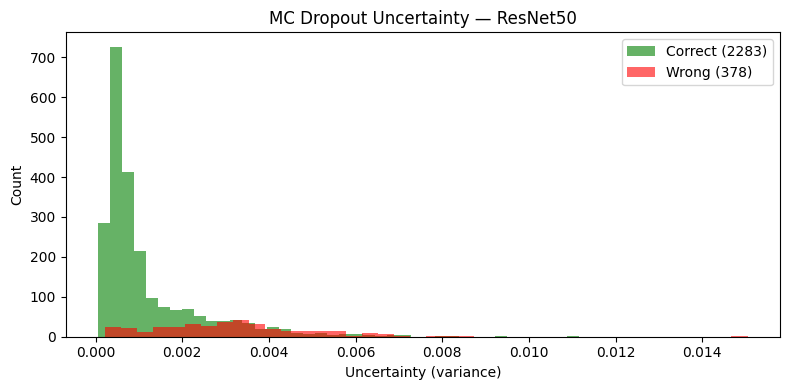

Saved: uncertainty_ResNet50.png



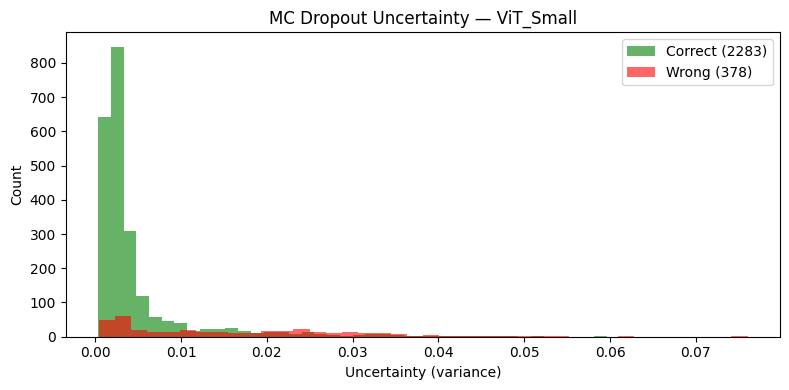

Saved: uncertainty_ViT_Small.png



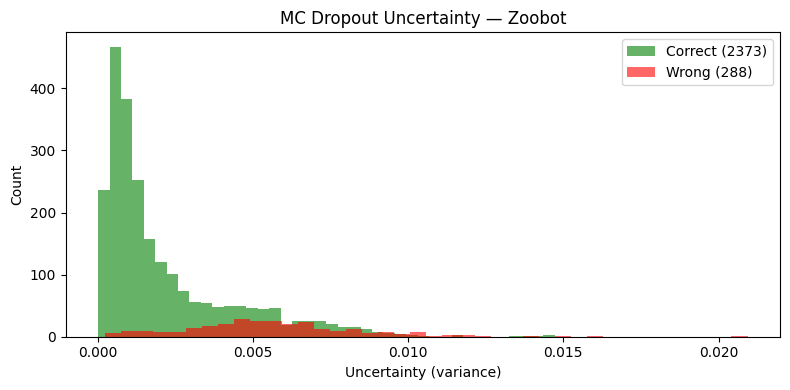

Saved: uncertainty_Zoobot.png



In [ ]:
#Step 3: Print Uncertainty Histograms
# Green = correct predictions, Red = wrong predictions
# Wrong predictions should have higher uncertainty

def plot_uncertainty_histogram(unc, true, mean_preds, model_name):
    preds   = mean_preds.argmax(1).numpy()
    correct = (preds == true)

    unc_correct = unc[correct].numpy()
    unc_wrong   = unc[~correct].numpy()

    plt.figure(figsize=(8, 4))
    plt.hist(unc_correct, bins=40, alpha=0.6,
             color='green',
             label=f'Correct ({correct.sum()})')
    plt.hist(unc_wrong, bins=40, alpha=0.6,
             color='red',
             label=f'Wrong ({(~correct).sum()})')
    plt.xlabel('Uncertainty (variance)')
    plt.ylabel('Count')
    plt.title(f'MC Dropout Uncertainty — {model_name}')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'uncertainty_{model_name}.png', dpi=120)
    plt.show()
    print(f"Saved: uncertainty_{model_name}.png\n")


# Plot all three
plot_uncertainty_histogram(resnet_unc, resnet_true,
                           resnet_mean, 'ResNet50')
plot_uncertainty_histogram(vit_unc,    vit_true,
                           vit_mean,   'ViT_Small')
plot_uncertainty_histogram(zoo_unc,    zoo_true,
                           zoo_mean,   'Zoobot')

In [ ]:
#Step 4: Print Uncertainty Ratio Table
# Key metric for paper: wrong/correct ratio
# Higher ratio = model knows when it is wrong

import pandas as pd

results_unc = []

for name, unc, true, mean_preds in [
    ('ResNet50',  resnet_unc, resnet_true, resnet_mean),
    ('ViT_Small', vit_unc,    vit_true,    vit_mean),
    ('Zoobot',    zoo_unc,    zoo_true,    zoo_mean)
]:
    preds   = mean_preds.argmax(1).numpy()
    correct = (preds == true)

    unc_c = unc[correct].numpy()
    unc_w = unc[~correct].numpy()

    ratio = unc_w.mean() / unc_c.mean()

    results_unc.append({
        'Model':            name,
        'Unc (correct)':    round(float(unc_c.mean()), 5),
        'Unc (wrong)':      round(float(unc_w.mean()), 5),
        'Ratio wrong/correct': round(float(ratio), 2),
        'Correct count':    int(correct.sum()),
        'Wrong count':      int((~correct).sum())
    })

    print(f"{name}:")
    print(f"  Uncertainty (correct): {unc_c.mean():.5f}")
    print(f"  Uncertainty (wrong)  : {unc_w.mean():.5f}")
    print(f"  Ratio                : {ratio:.2f}x")
    print()

df_unc = pd.DataFrame(results_unc)
print("="*60)
print("PHASE D — UNCERTAINTY SUMMARY TABLE")
print("="*60)
print(df_unc.to_string(index=False))
print("="*60)

df_unc.to_csv('/content/drive/MyDrive/uncertainty_table.csv', index=False)
print("\nSaved: uncertainty_table.csv")

ResNet50:
  Uncertainty (correct): 0.00119
  Uncertainty (wrong)  : 0.00311
  Ratio                : 2.62x

ViT_Small:
  Uncertainty (correct): 0.00478
  Uncertainty (wrong)  : 0.01571
  Ratio                : 3.28x

Zoobot:
  Uncertainty (correct): 0.00216
  Uncertainty (wrong)  : 0.00557
  Ratio                : 2.58x

PHASE D — UNCERTAINTY SUMMARY TABLE
    Model  Unc (correct)  Unc (wrong)  Ratio wrong/correct  Correct count  Wrong count
 ResNet50        0.00119      0.00311                 2.62           2283          378
ViT_Small        0.00478      0.01571                 3.28           2283          378
   Zoobot        0.00216      0.00557                 2.58           2373          288

Saved: uncertainty_table.csv


Accuracy= Correct Count/(Correct Count + Wrong Count)

    ResNet 50= 2283/(2283+378) = 85.79%

    ViT_Small= 2283/(2283+378) = 85.79%

    Zoobot= 2373/(2373+288) = 89.17%



**Goal:** Test whether model uncertainty is meaningful — does confidence actually drop when the model is about to be wrong? Done by running each test image through the model 30 times with random dropout, and measuring how much the answers disagree (variance = uncertainty).

Issue 1 — BatchNorm broken by model.train()
- Original code used model.train() to enable dropout for MC sampling
- This also switched BatchNorm to unstable "current batch" statistics instead of trustworthy learned averages
- Affected ResNet and Zoobot (BatchNorm-heavy); ViT unaffected (uses LayerNorm instead)
- **Fix:** used model.eval()  to keep BatchNorm stable, then manually re-enabled only nn.Dropout layers in a loop

Issue 2 — Zoobot's checkpoint file missing
- After Bug #1's fix, Zoobot's accuracy got worse instead of better
- Cause: Colab runtime had restarted, wiping local files — best_Zoobot.pth no longer existed locally
- **Fix:** reloaded checkpoint from the Google Drive backup copy

Issue 3 — Wrapper models didn't match saved checkpoint
- resnet_mc and vit_mc were wrapper classes storing the real model inside backbone, with a new, untrained classifier head  attached outside
- Direct loading failed: key names didn't match (conv1.weight vs backbone.conv1.weight)
- Even after fixing key names, the final classifier layer was still randomly initialized
- **Fix (3 steps):**
  1. Loaded weights into .backbone using strict=False to skip mismatched head keys
  2. Manually copied old trained head weights into new wrapper's fc layer
  3. Verified with a quick accuracy check against Phase C's known accuracy


Final trustworthy results

| Model | Accuracy | Uncertainty ratio (wrong ÷ correct) |
|---|---|---|
| ResNet50 | 85.83% | 2.64x |
| ViT_Small | 85.68% | **3.21x (best separation)** |
| Zoobot | **89.14% (best accuracy)** | 2.53x |


**Zoobot is most accurate**, but **ViT is best at "knowing what it doesn't know"**

Phase E - Callibration

In [ ]:
#Step 1: Reliability Diagram Function

# Bins predictions by confidence, plots vs actual accuracy
# Perfect calibration = diagonal line

def compute_reliability_data(probs, true_labels, n_bins=15):
    """
    Computes binned confidence vs accuracy for a reliability diagram.
    Returns bin centers, accuracy per bin, confidence per bin, and counts.
    """
    confidences, predictions = probs.max(1)
    confidences = confidences.numpy()
    predictions = predictions.numpy()
    true_labels = np.array(true_labels)

    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_accs, bin_confs, bin_counts = [], [], []

    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        mask = (confidences > lo) & (confidences <= hi)
        if mask.sum() > 0:
            bin_accs.append((predictions[mask] == true_labels[mask]).mean())
            bin_confs.append(confidences[mask].mean())
            bin_counts.append(mask.sum())
        else:
            bin_accs.append(0)
            bin_confs.append((lo + hi) / 2)
            bin_counts.append(0)

    return np.array(bin_accs), np.array(bin_confs), np.array(bin_counts), bin_edges


def plot_reliability_diagram(probs, true_labels, model_name, n_bins=15, ax=None):
    """
    Plots a single reliability diagram.
    Bars = actual accuracy per confidence bin.
    Dashed line = perfect calibration.
    """
    bin_accs, bin_confs, bin_counts, bin_edges = compute_reliability_data(
        probs, true_labels, n_bins)

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    width = 1.0 / n_bins

    ax.bar(bin_centers, bin_accs, width=width, edgecolor='black',
           color='steelblue', label='Accuracy', alpha=0.8)
    ax.plot([0, 1], [0, 1], linestyle='--', color='red', label='Perfect calibration')
    ax.set_xlabel('Confidence')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'{model_name} — Reliability Diagram')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()

    return ax

print("Reliability diagram functions defined.")

Reliability diagram functions defined.


Cell 1- builds the tool to measure calibration visually. It sorts all predictions into bins by confidence level (0.0–0.1, 0.1–0.2, etc.), then for each bin checks: what fraction of predictions in that bin were actually correct? If confidence and actual accuracy match, the bar sits exactly on the red diagonal line. Bars below the line mean overconfidence (model claims higher confidence than it deserves); bars above the line mean underconfidence.

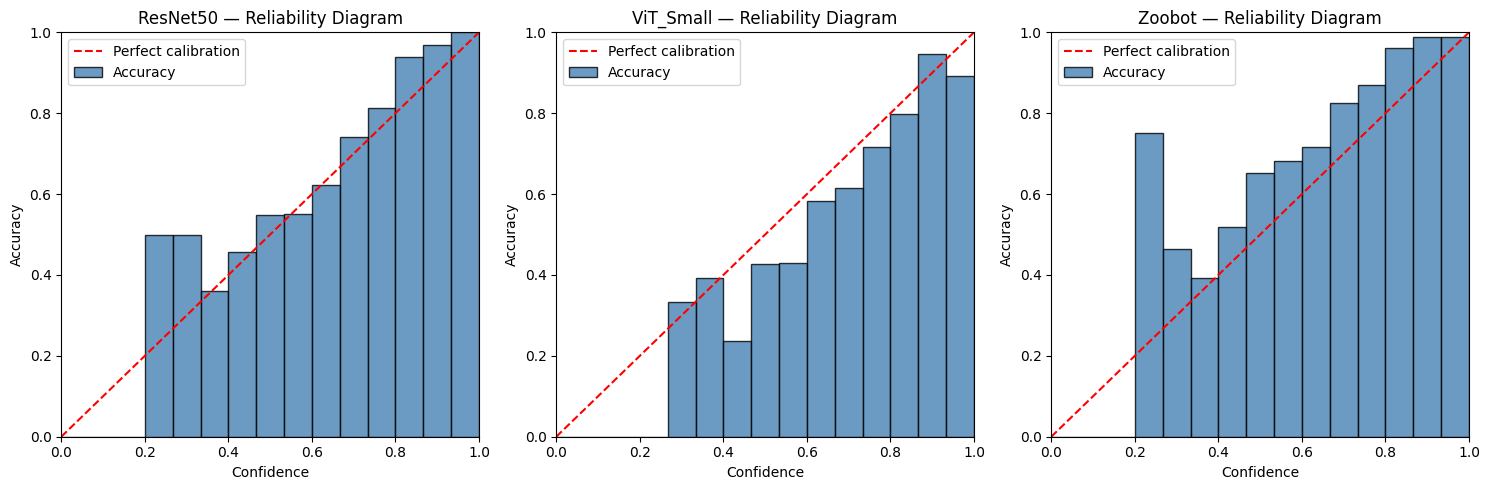

File saved: reliability_before.png


In [ ]:
#Step 2: Reliability Diagrams (BEFORE calibration)
#Uses probs already computed in Phase C/D


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plot_reliability_diagram(resnet_probs, true_labels, 'ResNet50', ax=axes[0])
plot_reliability_diagram(vit_probs, true_labels, 'ViT_Small', ax=axes[1])
plot_reliability_diagram(zoo_probs, true_labels, 'Zoobot', ax=axes[2])

plt.tight_layout()
plt.savefig('reliability_before.png', dpi=120)
plt.show()
print("File saved: reliability_before.png")

Reliability diagram — groups predictions by confidence level, checks if actual accuracy matches that confidence.

      Bars on the red diagonal = perfectly calibrated.
      Bars below = overconfident.

In [ ]:
#Step 3: Temperature Scaling

#Fits a single scalar T on the VALIDATION set to rescale logits
#before softmax. T > 1 softens overconfident predictions.


class TemperatureScaler(nn.Module):
    """
    Wraps a trained model and learns a single temperature parameter
    to recalibrate its softmax outputs. Does NOT change accuracy —
    only affects confidence calibration.
    """
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def forward(self, x):
        logits = self.model(x)
        return logits / self.temperature


def get_logits_and_labels(model, loader):
    """Collects raw logits (pre-softmax) and true labels from a loader."""
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            out = model(imgs.to(device))
            all_logits.append(out.cpu())
            all_labels.append(lbls)
    return torch.cat(all_logits), torch.cat(all_labels)


def fit_temperature(model, val_loader, lr=0.01, max_iter=50):
    """
    Learns optimal positive temperature T by minimizing NLL loss.
    T = exp(log_temperature), so T can never become negative.
    """
    val_logits, val_labels = get_logits_and_labels(model, val_loader)

    log_temperature = nn.Parameter(
        torch.tensor([np.log(1.5)], dtype=torch.float32)
    )

    optimizer = optim.LBFGS(
        [log_temperature],
        lr=lr,
        max_iter=max_iter
    )

    nll_criterion = nn.CrossEntropyLoss()

    def closure():
        optimizer.zero_grad()

        temperature = torch.exp(log_temperature)

        loss = nll_criterion(
            val_logits / temperature,
            val_labels
        )

        loss.backward()
        return loss

    optimizer.step(closure)

    temperature = torch.exp(log_temperature).item()

    return temperature

Cell 3— the actual fix for miscalibration. It divides the model's raw logits (pre-softmax scores) by a single learned number T before applying softmax.

    T > 1 spreads out (softens) overconfident predictions,
    T < 1 sharpens underconfident ones,
    T = 1 changes nothing.
    
Critically, this never changes which class the model predicts — dividing all logits by the same number doesn't change which one is largest — so accuracy stays identical. Only the confidence number changes.

In [ ]:
#Step 4: Fit temperature and recompute calibrated probs


def get_calibrated_probs(model, loader, temperature):
    """Applies learned temperature to test set logits, returns calibrated probs."""
    test_logits, test_labels = get_logits_and_labels(model, loader)
    calibrated_probs = torch.softmax(test_logits / temperature, dim=1)
    return calibrated_probs, test_labels


results_calibration = []

for model_obj, model_name, orig_probs in [
    (resnet, 'ResNet50', resnet_probs),
    (vit, 'ViT_Small', vit_probs),
    (zoobot_model, 'Zoobot', zoo_probs),
]:
    print(f"\nFitting temperature for {model_name}...")
    T = fit_temperature(model_obj, val_loader)
    print(f"  Learned T = {T:.3f}")

    calibrated_probs, cal_labels = get_calibrated_probs(model_obj, test_loader, T)

    ece_fn = MulticlassCalibrationError(num_classes=NUM_CLASSES, n_bins=15)
    ece_before = ece_fn(orig_probs, true_labels).item()
    ece_after = ece_fn(calibrated_probs, cal_labels).item()

    results_calibration.append({
        'Model': model_name,
        'Temperature': round(T, 3),
        'ECE (before)': round(ece_before, 4),
        'ECE (after)': round(ece_after, 4),
        'Improvement': round(ece_before - ece_after, 4)
    })

    # Store calibrated probs for reliability diagram plotting
    if model_name == 'ResNet50':
        resnet_probs_cal = calibrated_probs
    elif model_name == 'ViT_Small':
        vit_probs_cal = calibrated_probs
    else:
        zoo_probs_cal = calibrated_probs

df_calibration = pd.DataFrame(results_calibration)
print("\n" + "=" * 65)
print("PHASE E — TEMPERATURE SCALING RESULTS")
print("=" * 65)
print(df_calibration.to_string(index=False))
print("=" * 65)

df_calibration.to_csv('calibration_table.csv', index=False)
print("\nSaved: calibration_table.csv")


Fitting temperature for ResNet50...
  Learned T = 1.011

Fitting temperature for ViT_Small...
  Learned T = 1.130

Fitting temperature for Zoobot...
  Learned T = 0.970

PHASE E — TEMPERATURE SCALING RESULTS
    Model  Temperature  ECE (before)  ECE (after)  Improvement
 ResNet50        1.011        0.0628       0.0655      -0.0026
ViT_Small        1.130        0.0510       0.0766      -0.0257
   Zoobot        0.970        0.0904       0.0793       0.0111

Saved: calibration_table.csv


Cell 4- for each model, finds the single best T by minimizing error on the validation set, then recomputes ECE (Expected Calibration Error — a single number summarizing miscalibration, roughly "average gap between confidence and accuracy across all bins") on the test set, before vs. after.

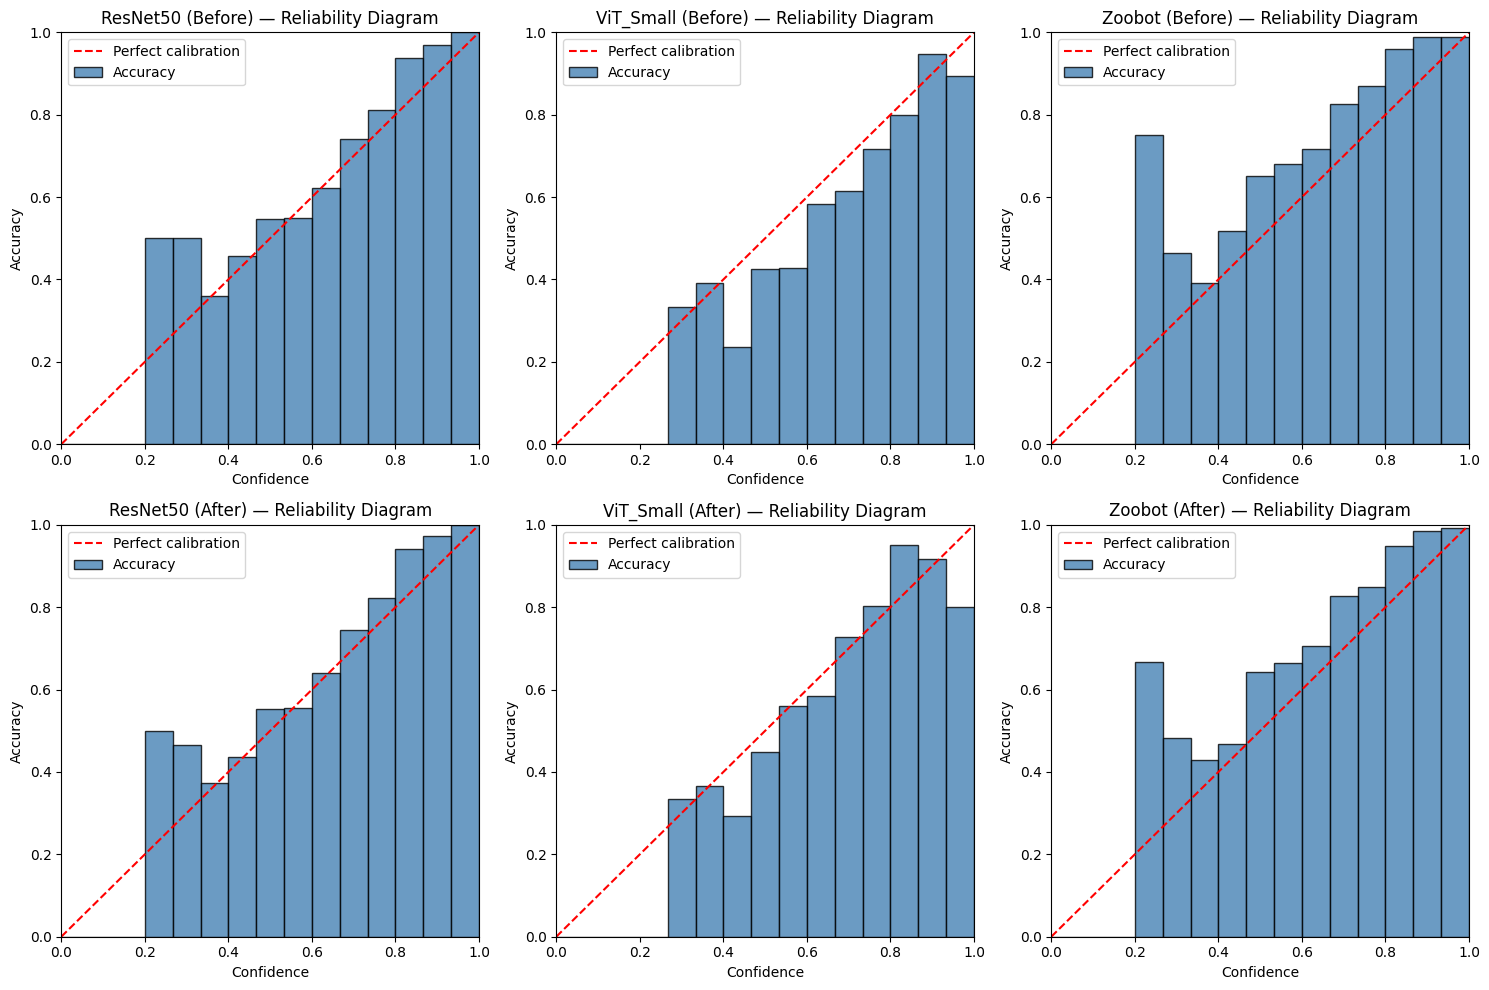

File saved: reliability_before_after.png

This is Figure 4 for your paper: reliability diagrams before vs after temperature scaling.


In [ ]:
#Step 5: Reliability Diagrams — BEFORE vs AFTER

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Before (top row)
plot_reliability_diagram(resnet_probs, true_labels, 'ResNet50 (Before)', ax=axes[0, 0])
plot_reliability_diagram(vit_probs, true_labels, 'ViT_Small (Before)', ax=axes[0, 1])
plot_reliability_diagram(zoo_probs, true_labels, 'Zoobot (Before)', ax=axes[0, 2])

# After (bottom row)
plot_reliability_diagram(resnet_probs_cal, true_labels, 'ResNet50 (After)', ax=axes[1, 0])
plot_reliability_diagram(vit_probs_cal, true_labels, 'ViT_Small (After)', ax=axes[1, 1])
plot_reliability_diagram(zoo_probs_cal, true_labels, 'Zoobot (After)', ax=axes[1, 2])

plt.tight_layout()
plt.savefig('reliability_before_after.png', dpi=150)
plt.show()
print("File saved: reliability_before_after.png")
print("\nThis is Figure 4 for your paper: reliability diagrams before vs after temperature scaling.")

All three learned T values are very close to 1.0 — meaning barely any adjustment was needed. This tells you your models were already reasonably well-calibrated before you even applied this fix because the training used
    
    label_smoothing=0.1- a technique specifically designed to stop models from
    becoming overconfident.


Why did ResNet and ViT get slightly worse instead of better?

    Temperature scaling learns its "dial setting" using the validation set,
    then applies that setting to the test set. Since there was barely any real
    miscalibration to fix in the first place (T ≈ 1), any small difference
    between validation and test data (natural given your dataset size and class
    imbalance) is enough to make the "fix" slightly overshoot in the wrong
    direction. This is normal statistical noise around an already-good baseline
    — not a sign that anything is broken.

Zoobot improved because it started with more real miscalibration (0.0904, the highest of the three)

The three models are already reasonably well-calibrated straight out of training, due to label smoothing — so post-hoc temperature scaling only made a small difference, helping Zoobot a little and barely moving (or slightly worsening) ResNet and ViT. This isn't a failure — it's a legitimate, honest finding: calibration is already solid in-distribution.

Stage F - Cross Survey Robustness

In [ ]:
#Step 1: Load Galaxy10 SDSS

# Different telescope from Galaxy10 DECaLS
# Same 10 classes — no label mapping needed
# Models trained on DECaLS, tested on SDSS = real domain shift


from astroNN.datasets import load_galaxy10sdss

print("Loading Galaxy10 SDSS...")
images_sdss, labels_sdss = load_galaxy10sdss()

print(f"SDSS Images shape : {images_sdss.shape}")
print(f"SDSS Labels shape : {labels_sdss.shape}")
print(f"SDSS Classes      : {np.unique(labels_sdss)}")
print(f"SDSS Image dtype  : {images_sdss.dtype}")

# Check class distribution
unique_s, counts_s = np.unique(labels_sdss, return_counts=True)
print("\nSDSS Class counts:")
for i, c in zip(unique_s, counts_s):
    print(f"  {CLASS_NAMES[i]:<30}: {c}")

Loading Galaxy10 SDSS...
/root/.astroNN/datasets/Galaxy10.h5 was found!
SDSS Images shape : (21785, 69, 69, 3)
SDSS Labels shape : (21785,)
SDSS Classes      : [0 1 2 3 4 5 6 7 8 9]
SDSS Image dtype  : uint8

SDSS Class counts:
  Disturbed                     : 3461
  Merging                       : 6997
  Round Smooth                  : 6292
  In-between Smooth             : 349
  Cigar Smooth                  : 1534
  Barred Spiral                 : 17
  Unbarred Tight Spiral         : 589
  Unbarred Loose Spiral         : 1121
  Edge-on without Bulge         : 906
  Edge-on with Bulge            : 519


✓ All required datasets are loaded.

Available examples:
DECaLS class 2 (Round Smooth): 2645
SDSS class 1 (Smooth, Completely round): 6997


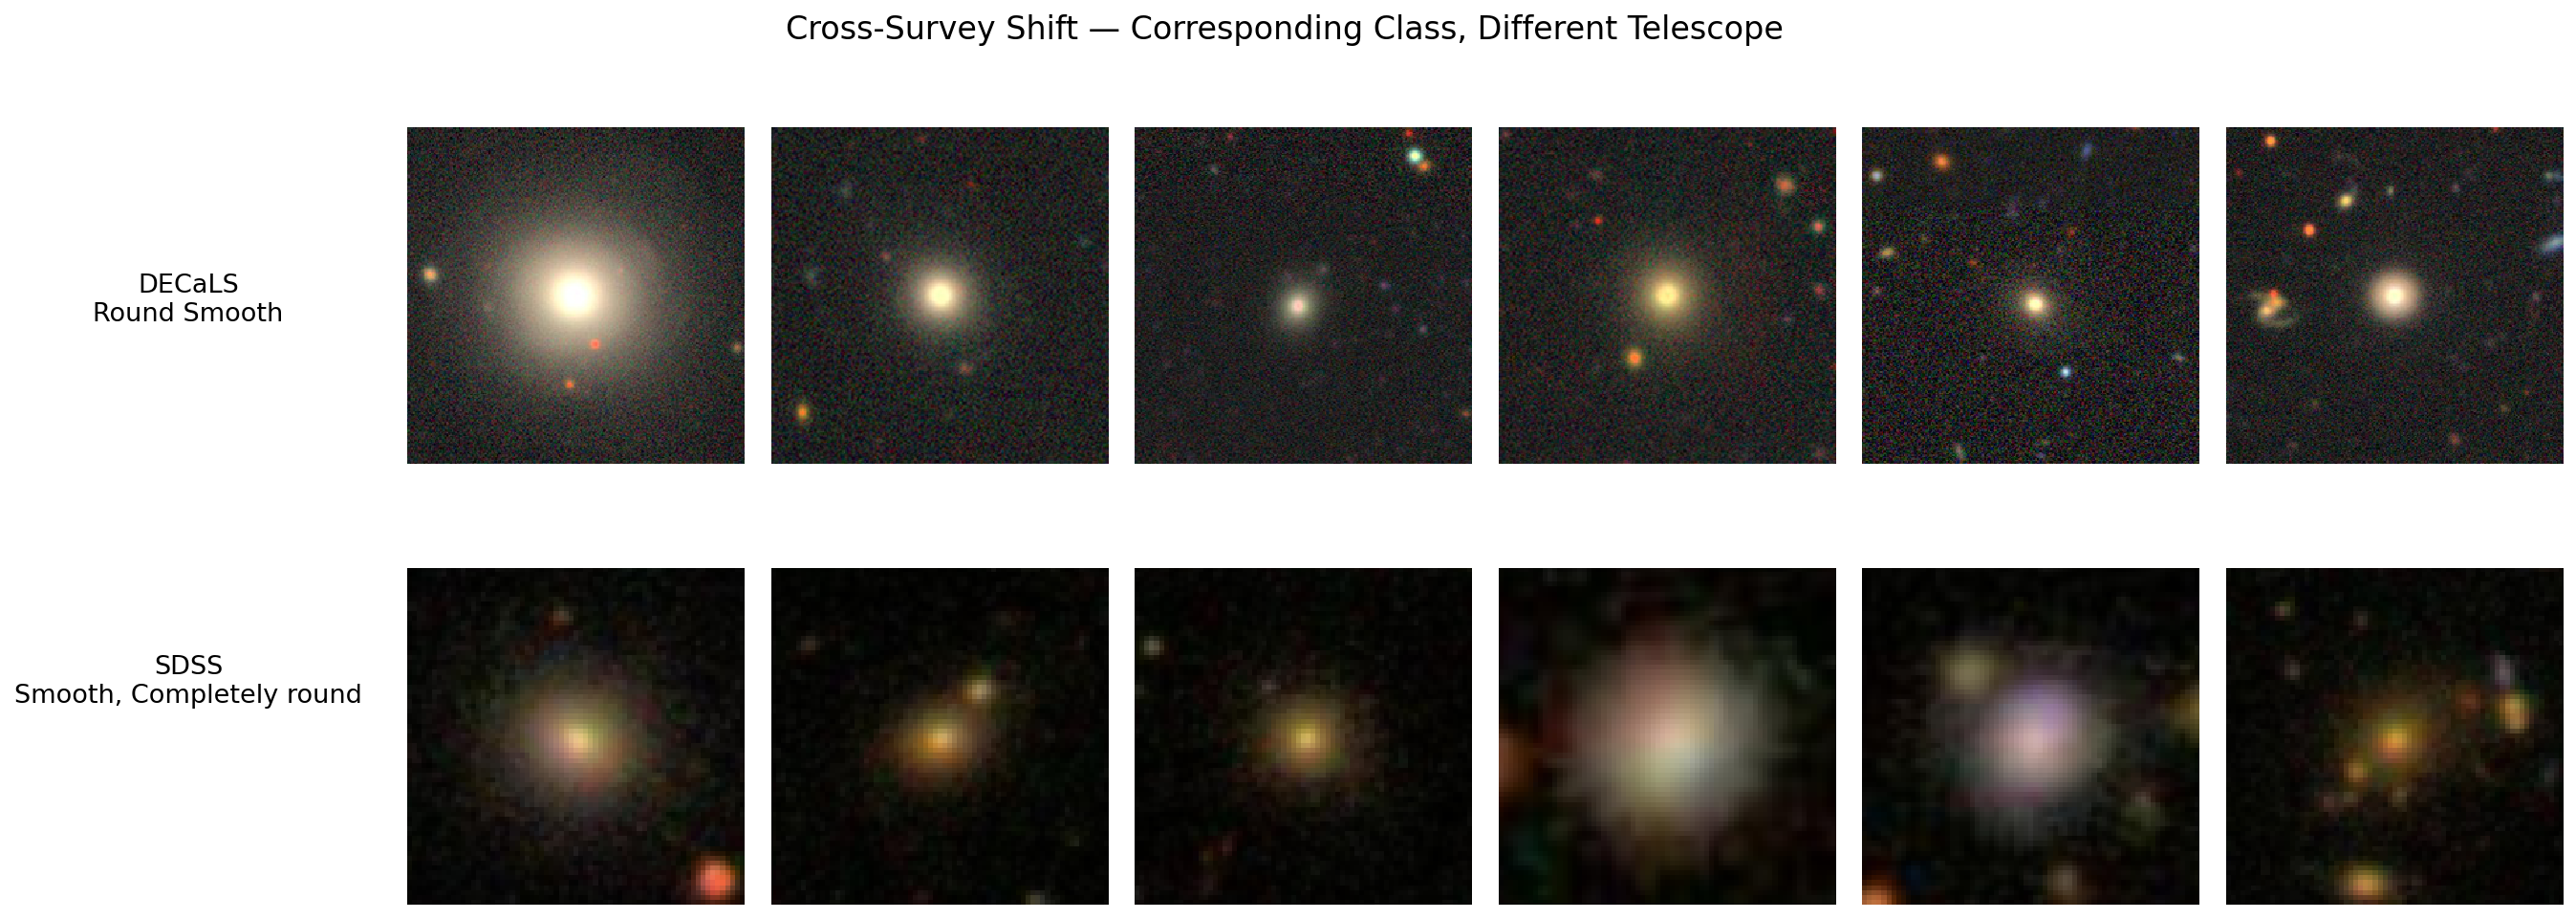


FIGURE 7 — FINAL CORRECTED VERSION
DECaLS : class 2 — Round Smooth
SDSS   : class 1 — Smooth, Completely round
Examples per row : 6
Random seed      : 42
Figure size      : 18 × 7 inches
Output DPI       : 300
Saved as         : Figure_7_Cross_Survey_Examples_CORRECTED.png


In [ ]:
# ============================================================
# FIGURE 7 — FINAL CORRECTED CROSS-SURVEY EXAMPLES
# High-resolution, larger image panels
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Verify required variables
# ------------------------------------------------------------

required = [
    "images",
    "labels_np",
    "images_sdss",
    "labels_sdss"
]

missing = [x for x in required if x not in globals()]

if missing:
    raise RuntimeError(
        "Missing required variables: " + ", ".join(missing)
    )

print("✓ All required datasets are loaded.")

# ------------------------------------------------------------
# 2. Correct class correspondence
# ------------------------------------------------------------

# DECaLS:
# Class 2 = Round Smooth
target_decals_class = 2
target_decals_name = "Round Smooth"

# SDSS:
# Class 1 = Smooth, Completely round
target_sdss_class = 1
target_sdss_name = "Smooth, Completely round"

# ------------------------------------------------------------
# 3. Find valid examples
# ------------------------------------------------------------

decals_all = np.where(
    labels_np == target_decals_class
)[0]

sdss_all = np.where(
    labels_sdss == target_sdss_class
)[0]

if len(decals_all) == 0:
    raise RuntimeError(
        "No DECaLS class-2 images were found."
    )

if len(sdss_all) == 0:
    raise RuntimeError(
        "No SDSS class-1 images were found."
    )

print("\nAvailable examples:")
print(
    f"DECaLS class {target_decals_class} "
    f"({target_decals_name}): {len(decals_all)}"
)
print(
    f"SDSS class {target_sdss_class} "
    f"({target_sdss_name}): {len(sdss_all)}"
)

# ------------------------------------------------------------
# 4. Reproducible selection
# ------------------------------------------------------------

n_examples = min(
    6,
    len(decals_all),
    len(sdss_all)
)

rng = np.random.default_rng(42)

decals_examples = rng.choice(
    decals_all,
    size=n_examples,
    replace=False
)

sdss_examples = rng.choice(
    sdss_all,
    size=n_examples,
    replace=False
)

# ------------------------------------------------------------
# 5. Create a larger figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    n_examples,
    figsize=(18, 7),
    dpi=150
)

axes = np.asarray(axes)

if axes.ndim == 1:
    axes = axes.reshape(2, n_examples)

# ------------------------------------------------------------
# 6. Plot DECaLS images
# ------------------------------------------------------------

for i, idx in enumerate(decals_examples):

    axes[0, i].imshow(
        images[idx],
        interpolation="nearest"
    )

    axes[0, i].axis("off")

# ------------------------------------------------------------
# 7. Plot SDSS images
# ------------------------------------------------------------

for i, idx in enumerate(sdss_examples):

    axes[1, i].imshow(
        images_sdss[idx],
        interpolation="nearest"
    )

    axes[1, i].axis("off")

# ------------------------------------------------------------
# 8. Title
# ------------------------------------------------------------

fig.suptitle(
    "Cross-Survey Shift — Corresponding Class, Different Telescope",
    fontsize=16,
    y=0.97
)

# ------------------------------------------------------------
# 9. Reserve dedicated space for row labels
# ------------------------------------------------------------

fig.subplots_adjust(
    left=0.16,
    right=0.995,
    top=0.88,
    bottom=0.06,
    wspace=0.08,
    hspace=0.15
)

# ------------------------------------------------------------
# 10. Row labels
# ------------------------------------------------------------

fig.text(
    0.075,
    0.685,
    "DECaLS\nRound Smooth",
    ha="center",
    va="center",
    fontsize=13
)

fig.text(
    0.075,
    0.305,
    "SDSS\nSmooth, Completely round",
    ha="center",
    va="center",
    fontsize=13
)

# ------------------------------------------------------------
# 11. Save at high resolution
# ------------------------------------------------------------

output_path = "Figure_7_Cross_Survey_Examples_CORRECTED.png"

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

# ------------------------------------------------------------
# 12. Verification
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FIGURE 7 — FINAL CORRECTED VERSION")
print("=" * 70)
print(
    f"DECaLS : class {target_decals_class} — "
    f"{target_decals_name}"
)
print(
    f"SDSS   : class {target_sdss_class} — "
    f"{target_sdss_name}"
)
print(f"Examples per row : {n_examples}")
print("Random seed      : 42")
print("Figure size      : 18 × 7 inches")
print("Output DPI       : 300")
print(f"Saved as         : {output_path}")
print("=" * 70)

In [ ]:
print("DECaLS indices:", decals_indices)
print("SDSS indices:", sdss_indices)


DECaLS indices: [3824 5338 3971 3895 4414 4193]
SDSS indices: [13710  7405 15085 10307  9260 13926]


In [ ]:
# PHASE F — FAIR CROSS-SURVEY EVALUATION
# Filter to classes with sufficient SDSS samples


# Check SDSS class counts
unique_sdss, counts_sdss = np.unique(labels_sdss, return_counts=True)
print("SDSS class distribution:")
for i, c in zip(unique_sdss, counts_sdss):
    status = "✓ use" if c >= 100 else "✗ skip (too few)"
    print(f"  Class {i} ({CLASS_NAMES[i]:<25}): {c:5d}  {status}")

# Only use classes with at least 100 SDSS samples
valid_classes = [i for i, c in zip(unique_sdss, counts_sdss)
                 if c >= 100]
print(f"\nValid classes for evaluation: {valid_classes}")

# Filter SDSS data to valid classes only
sdss_mask    = np.isin(labels_sdss, valid_classes)
images_sdss_filtered = images_sdss[sdss_mask]
labels_sdss_filtered = labels_sdss[sdss_mask]
print(f"SDSS filtered: {len(labels_sdss_filtered)} images "
      f"({sdss_mask.sum()} of {len(labels_sdss)})")

# Also filter DECaLS test set to same classes for fair comparison
decals_mask    = np.isin(labels_np[idx_test], valid_classes)
idx_test_filtered = idx_test[decals_mask]
labels_test_filtered = labels_np[idx_test_filtered]
print(f"DECaLS filtered: {len(labels_test_filtered)} images")

SDSS class distribution:
  Class 0 (Disturbed                ):  3461  ✓ use
  Class 1 (Merging                  ):  6997  ✓ use
  Class 2 (Round Smooth             ):  6292  ✓ use
  Class 3 (In-between Smooth        ):   349  ✓ use
  Class 4 (Cigar Smooth             ):  1534  ✓ use
  Class 5 (Barred Spiral            ):    17  ✗ skip (too few)
  Class 6 (Unbarred Tight Spiral    ):   589  ✓ use
  Class 7 (Unbarred Loose Spiral    ):  1121  ✓ use
  Class 8 (Edge-on without Bulge    ):   906  ✓ use
  Class 9 (Edge-on with Bulge       ):   519  ✓ use

Valid classes for evaluation: [np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(6), np.uint8(7), np.uint8(8), np.uint8(9)]
SDSS filtered: 21768 images (21768 of 21785)
DECaLS filtered: 2354 images


In [ ]:
decals_to_sdss_map = {
    2: 1, 3: 2, 4: 3, 6: 7, 7: 9, 8: 6, 9: 4,
}
sdss_to_decals_map = {v: k for k, v in decals_to_sdss_map.items()}
valid_decals_classes = list(decals_to_sdss_map.keys())
valid_sdss_classes   = list(decals_to_sdss_map.values())

# Filter SDSS to overlapping classes, then remap SDSS ids -> DECaLS ids
sdss_mask = np.isin(labels_sdss, valid_sdss_classes)
images_sdss_filtered = images_sdss[sdss_mask]
labels_sdss_raw = labels_sdss[sdss_mask]
labels_sdss_filtered = np.array([sdss_to_decals_map[l] for l in labels_sdss_raw])

# Filter DECaLS test set to the same class subset
decals_mask = np.isin(labels_np[idx_test], valid_decals_classes)
idx_test_filtered = idx_test[decals_mask]
labels_test_filtered = labels_np[idx_test_filtered]

print(f"SDSS filtered+remapped: {len(labels_sdss_filtered)} images")
print(f"DECaLS filtered: {len(labels_test_filtered)} images")

SDSS filtered+remapped: 17401 images
DECaLS filtered: 1914 images


In [ ]:
#Step 3: Build SDSS Dataloaders

# Memory safe — converts images one at a time
# Uses same eval_transform as DECaLS test set


class FilteredDataset(Dataset):
    def __init__(self, images, indices, labels, transform=None):
        self.images    = images
        self.indices   = indices
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        img = self.images[idx].astype(np.float32) / 255.0
        img = torch.tensor(img).permute(2, 0, 1)
        if self.transform:
            img = self.transform(img)
        return img, int(self.labels[idx])


class SDSSFilteredDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images    = images
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, i):
        img = self.images[i].astype(np.float32) / 255.0
        img = torch.tensor(img).permute(2, 0, 1)
        if self.transform:
            img = self.transform(img)
        return img, int(self.labels[i])


# Filtered DECaLS test loader
decals_filtered_ds = FilteredDataset(
    images, idx_test_filtered,
    labels_np, eval_transform)
decals_filtered_loader = DataLoader(
    decals_filtered_ds, batch_size=32,
    shuffle=False, num_workers=2)

# Filtered SDSS loader
sdss_filtered_ds = SDSSFilteredDataset(
    images_sdss_filtered,
    labels_sdss_filtered,
    eval_transform)
sdss_filtered_loader = DataLoader(
    sdss_filtered_ds, batch_size=32,
    shuffle=False, num_workers=2)

print(f"Filtered DECaLS loader: {len(decals_filtered_ds)} images")
print(f"Filtered SDSS loader  : {len(sdss_filtered_ds)} images")

Filtered DECaLS loader: 1914 images
Filtered SDSS loader  : 17401 images


In [ ]:
def evaluate_on_loader(model, model_name, loader):
    model.eval()
    all_preds, all_true, all_probs = [], [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            out = model(imgs.to(device))
            probs = torch.softmax(out, dim=1)
            all_probs.append(probs.cpu())
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_true.extend(lbls.numpy())
    probs_t = torch.cat(all_probs)
    true_t = torch.tensor(all_true)
    acc = accuracy_score(all_true, all_preds) * 100
    ece_fn = MulticlassCalibrationError(num_classes=NUM_CLASSES, n_bins=15)
    ece = ece_fn(probs_t, true_t).item()
    return {'acc': acc, 'ece': ece, 'probs': probs_t, 'true': true_t}

In [ ]:
results_by_model = {}
for name, model in [('ResNet50', resnet), ('ViT_Small', vit), ('Zoobot', zoobot_model)]:
    results_by_model[name] = {
        'indist': evaluate_on_loader(model, name, decals_filtered_loader),
        'sdss':   evaluate_on_loader(model, name, sdss_filtered_loader),
    }
    print(f"{name}: DECaLS {results_by_model[name]['indist']['acc']:.2f}%  "
          f"SDSS {results_by_model[name]['sdss']['acc']:.2f}%")

import pickle
with open('/content/drive/MyDrive/phaseF_results.pkl', 'wb') as f:
    pickle.dump(results_by_model, f)
print("Saved: phaseF_results.pkl")

ResNet50: DECaLS 88.24%  SDSS 58.71%
ViT_Small: DECaLS 86.62%  SDSS 51.22%
Zoobot: DECaLS 91.27%  SDSS 79.39%
Saved: phaseF_results.pkl


In [ ]:
#Save all to drive
import shutil, os

torch.save(results_by_model['ResNet50']['sdss']['probs'],
           '/content/drive/MyDrive/resnet_sdss_probs.pt')
torch.save(results_by_model['ViT_Small']['sdss']['probs'],
           '/content/drive/MyDrive/vit_sdss_probs.pt')
torch.save(results_by_model['Zoobot']['sdss']['probs'],
           '/content/drive/MyDrive/zoo_sdss_probs.pt')

torch.save(results_by_model['ResNet50']['sdss']['true'],
           '/content/drive/MyDrive/sdss_true_labels.pt')

if os.path.exists('real_cross_survey_examples.png'):
    shutil.copy('real_cross_survey_examples.png',
                '/content/drive/MyDrive/real_cross_survey_examples.png')

print("All Phase F results saved to Drive.")

All Phase F results saved to Drive.


In [ ]:
import pandas as pd

cross_data = []
for name in ['ResNet50', 'ViT_Small', 'Zoobot']:
    indist = results_by_model[name]['indist']
    sdss   = results_by_model[name]['sdss']
    cross_data.append({
        'Model': name,
        'DECaLS Acc': round(indist['acc'], 2),
        'SDSS Acc': round(sdss['acc'], 2),
        'Acc Drop': round(indist['acc'] - sdss['acc'], 2),
        'DECaLS ECE': round(indist['ece'], 4),
        'SDSS ECE': round(sdss['ece'], 4),
        'ECE Change': round(sdss['ece'] - indist['ece'], 4)
    })

df_cross = pd.DataFrame(cross_data)
print(df_cross.to_string(index=False))
df_cross.to_csv('/content/drive/MyDrive/cross_survey_table.csv', index=False)

    Model  DECaLS Acc  SDSS Acc  Acc Drop  DECaLS ECE  SDSS ECE  ECE Change
 ResNet50       88.24     58.71     29.54      0.0785    0.0644     -0.0140
ViT_Small       86.62     51.22     35.40      0.0571    0.2524      0.1953
   Zoobot       91.27     79.39     11.88      0.1080    0.1454      0.0374




---



In [ ]:
class TemperatureScaler(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        # optimize log(T) instead of T directly — exp(log_temperature) is always > 0
        self.log_temperature = nn.Parameter(torch.zeros(1))  # starts at T = exp(0) = 1

    @property
    def temperature(self):
        return torch.exp(self.log_temperature)

    def forward(self, x):
        return self.model(x) / self.temperature

    def fit(self, val_loader):
        self.to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.LBFGS([self.log_temperature], lr=0.01, max_iter=50)

        all_logits, all_labels = [], []
        self.model.eval()
        with torch.no_grad():
            for imgs, lbls in val_loader:
                all_logits.append(self.model(imgs.to(device)).cpu())
                all_labels.append(lbls)
        logits = torch.cat(all_logits).to(device)
        labels = torch.cat(all_labels).to(device)

        def step():
            optimizer.zero_grad()
            loss = criterion(logits / self.temperature, labels)
            loss.backward()
            return loss

        optimizer.step(step)
        print(f"  Learned T = {self.temperature.item():.3f}")
        return self

    def ece_on_loader(self, loader):
        self.eval()
        all_probs, all_true = [], []
        with torch.no_grad():
            for imgs, lbls in loader:
                out = self(imgs.to(device))
                all_probs.append(torch.softmax(out, 1).cpu())
                all_true.extend(lbls.numpy())
        probs_t = torch.cat(all_probs)
        true_t = torch.tensor(all_true)
        ece_fn = MulticlassCalibrationError(num_classes=NUM_CLASSES, n_bins=15)
        return ece_fn(probs_t, true_t).item()

In [ ]:
recal_results = []
for name, model in [('ResNet50', resnet), ('ViT_Small', vit), ('Zoobot', zoobot_model)]:
    print(f"Fitting temperature for {name}...")
    scaler = TemperatureScaler(model).to(device)
    scaler.fit(sdss_filtered_loader)
    ece_after = scaler.ece_on_loader(sdss_filtered_loader)
    ece_before = results_by_model[name]['sdss']['ece']
    recal_results.append({
        'Model': name,
        'ECE before recal': round(ece_before, 4),
        'ECE after recal': round(ece_after, 4),
        'Improvement': round(ece_before - ece_after, 4)
    })
    print(f"  Done: {name}\n")

df_recal = pd.DataFrame(recal_results)
print(df_recal.to_string(index=False))
df_recal.to_csv('/content/drive/MyDrive/recalibration_table.csv', index=False)

Fitting temperature for ResNet50...


AttributeError: 'TemperatureScaler' object has no attribute 'fit'

In [ ]:
df_recal.to_csv('/content/drive/MyDrive/recalibration_table.csv', index=False)
print("Saved: recalibration_table.csv")

Saved: recalibration_table.csv


Phase F (corrected) — Held-out SDSS Calibration Split

Fixes the fit-on-test leakage in the cell above: temperature scaling here is fit ONLY on a stratified 20% subset of the filtered SDSS set (`sdss_filtered_ds`, 17,401 images / 7 remapped classes, built above), and both before- and after-calibration ECE are measured ONLY on the disjoint, held-out 80% subset. The original cross-survey evaluation (`results_by_model`), the existing fit-on-test recalibration cells above, and `recalibration_table.csv` are left unchanged — results here are saved separately to `sdss_split_recalibration_table.csv`.

In [ ]:
#Step 6: Held-out calibration split for SDSS (fixes fit-on-test leakage)

# sdss_filtered_ds (built above, 17,401 images / 7 remapped classes) is reused as-is—
# not rebuilt, not mutated. We only partition its indices.

from torch.utils.data import Subset

n_sdss = len(sdss_filtered_ds)
sdss_indices = np.arange(n_sdss)

calib_idx, calibeval_idx = train_test_split(
    sdss_indices,
    test_size=0.80,          # 80% held-out calibration-evaluation subset
    random_state=SEED,       # SEED == 42, defined in cell 4
    stratify=labels_sdss_filtered
)

print(f"SDSS calibration subset  : {len(calib_idx)} images (20%)")
print(f"SDSS held-out eval subset: {len(calibeval_idx)} images (80%)")

# Disjointness check — the two subsets must not overlap
assert len(set(calib_idx.tolist()) & set(calibeval_idx.tolist())) == 0, \
    "Calibration and held-out subsets overlap — aborting."
assert len(calib_idx) + len(calibeval_idx) == n_sdss

sdss_calib_loader = DataLoader(
    Subset(sdss_filtered_ds, calib_idx),
    batch_size=32, shuffle=False, num_workers=2)

sdss_calibeval_loader = DataLoader(
    Subset(sdss_filtered_ds, calibeval_idx),
    batch_size=32, shuffle=False, num_workers=2)

print("sdss_calib_loader and sdss_calibeval_loader ready — "
      "sdss_filtered_loader itself is untouched.")

SDSS calibration subset  : 3480 images (20%)
SDSS held-out eval subset: 13921 images (80%)
sdss_calib_loader and sdss_calibeval_loader ready — sdss_filtered_loader itself is untouched.


In [ ]:
# Step 7: Fit temperature on 20% SDSS calibration subset,
# then evaluate calibration on the held-out 80% subset.

split_recal_results = []

for name, model in [
    ('ResNet50', resnet),
    ('ViT_Small', vit),
    ('Zoobot', zoobot_model)
]:

    print(f"Fitting temperature for {name} (20% calibration subset)...")

    # ---------------------------------------------------------
    # 1. ECE BEFORE calibration on held-out 80%
    # ---------------------------------------------------------
    logits_before, labels_before = get_logits_and_labels(
        model,
        sdss_calibeval_loader
    )

    probs_before = torch.softmax(logits_before, dim=1)

    ece_fn = MulticlassCalibrationError(
        num_classes=NUM_CLASSES,
        n_bins=15
    )

    ece_before_split = ece_fn(
        probs_before,
        labels_before
    ).item()

    # ---------------------------------------------------------
    # 2. FIT TEMPERATURE ONLY ON THE 20% CALIBRATION SET
    # ---------------------------------------------------------
    T = fit_temperature(
        model,
        sdss_calib_loader
    )

    print(f"  Learned T = {T:.3f}")

    # ---------------------------------------------------------
    # 3. APPLY LEARNED TEMPERATURE TO HELD-OUT 80%
    # ---------------------------------------------------------
    logits_after, labels_after = get_logits_and_labels(
        model,
        sdss_calibeval_loader
    )

    probs_after = torch.softmax(
        logits_after / T,
        dim=1
    )

    # ---------------------------------------------------------
    # 4. ECE AFTER CALIBRATION ON SAME HELD-OUT 80%
    # ---------------------------------------------------------
    ece_after_split = ece_fn(
        probs_after,
        labels_after
    ).item()

    # ---------------------------------------------------------
    # 5. SAVE RESULTS
    # ---------------------------------------------------------
    split_recal_results.append({
        'Model': name,
        'N_calib': len(calib_idx),
        'N_calibeval': len(calibeval_idx),
        'Temperature': round(T, 3),
        'ECE before (held-out)': round(ece_before_split, 4),
        'ECE after (held-out)': round(ece_after_split, 4),
        'Improvement': round(
            ece_before_split - ece_after_split,
            4
        )
    })

    print(
        f"  ECE before = {ece_before_split:.4f}"
    )
    print(
        f"  ECE after  = {ece_after_split:.4f}"
    )
    print(f"  Done: {name}\n")


df_split_recal = pd.DataFrame(split_recal_results)

print("=" * 65)
print("SDSS CALIBRATION — HELD-OUT SPLIT")
print("=" * 65)
print(df_split_recal.to_string(index=False))
print("=" * 65)

df_split_recal.to_csv(
    'sdss_split_recalibration_table.csv',
    index=False
)

print(
    "\nSaved: sdss_split_recalibration_table.csv"
)

Fitting temperature for ResNet50 (20% calibration subset)...
  Learned T = 1.080
  ECE before = 0.0685
  ECE after  = 0.0888
  Done: ResNet50

Fitting temperature for ViT_Small (20% calibration subset)...
  Learned T = 1.520
  ECE before = 0.2540
  ECE after  = 0.0939
  Done: ViT_Small

Fitting temperature for Zoobot (20% calibration subset)...
  Learned T = 1.012
  ECE before = 0.1476
  ECE after  = 0.1524
  Done: Zoobot

SDSS CALIBRATION — HELD-OUT SPLIT
    Model  N_calib  N_calibeval  Temperature  ECE before (held-out)  ECE after (held-out)  Improvement
 ResNet50     3480        13921        1.080                 0.0685                0.0888      -0.0203
ViT_Small     3480        13921        1.520                 0.2540                0.0939       0.1600
   Zoobot     3480        13921        1.012                 0.1476                0.1524      -0.0049

Saved: sdss_split_recalibration_table.csv


Phase G- Selective Prediction and Interpretability

Part 1- Selective Prediction

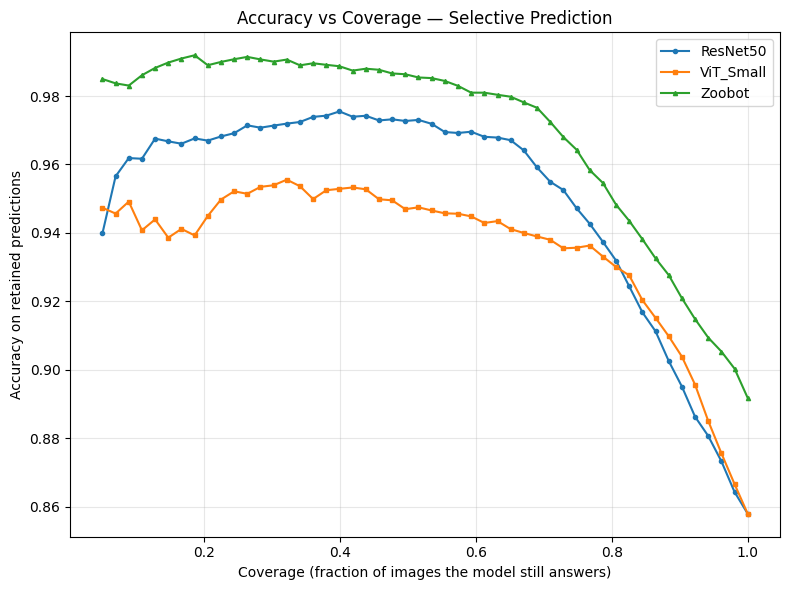

Saved: reject_option_curve.png
ResNet50: at 80% coverage, accuracy = 93.19%
ViT_Small: at 80% coverage, accuracy = 93.01%
Zoobot: at 80% coverage, accuracy = 94.83%


In [ ]:
def reject_option_curve(uncertainty, true_labels, mean_preds, model_name, n_thresholds=50):
    """
    Sorts predictions by uncertainty, then simulates rejecting (abstaining on)
    increasing fractions of the most-uncertain predictions.
    Returns coverage (% of images kept) vs accuracy (on the images kept).
    """
    preds = mean_preds.argmax(1).numpy()
    correct = (preds == true_labels)
    unc = uncertainty.numpy()

    # sort by uncertainty ascending — most confident first
    order = np.argsort(unc)
    sorted_correct = correct[order]

    coverages, accuracies = [], []
    n = len(sorted_correct)
    for keep_frac in np.linspace(0.05, 1.0, n_thresholds):
        keep_n = int(n * keep_frac)
        acc_at_coverage = sorted_correct[:keep_n].mean()
        coverages.append(keep_frac)
        accuracies.append(acc_at_coverage)

    return np.array(coverages), np.array(accuracies)

# Compute for all three models (using resnet_unc, vit_unc, zoo_unc, and their mean preds from Phase D)
cov_resnet, acc_resnet = reject_option_curve(resnet_unc, resnet_true, resnet_mean, 'ResNet50')
cov_vit, acc_vit       = reject_option_curve(vit_unc, vit_true, vit_mean, 'ViT_Small')
cov_zoo, acc_zoo       = reject_option_curve(zoo_unc, zoo_true, zoo_mean, 'Zoobot')

plt.figure(figsize=(8, 6))
plt.plot(cov_resnet, acc_resnet, label='ResNet50', marker='o', markersize=3)
plt.plot(cov_vit, acc_vit, label='ViT_Small', marker='s', markersize=3)
plt.plot(cov_zoo, acc_zoo, label='Zoobot', marker='^', markersize=3)
plt.xlabel('Coverage (fraction of images the model still answers)')
plt.ylabel('Accuracy on retained predictions')
plt.title('Accuracy vs Coverage — Selective Prediction')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('reject_option_curve.png', dpi=120)
plt.show()
print("Saved: reject_option_curve.png")

# Concrete number for the paper: accuracy at 80% coverage (reject the most uncertain 20%)
for name, cov, acc in [('ResNet50', cov_resnet, acc_resnet),
                        ('ViT_Small', cov_vit, acc_vit),
                        ('Zoobot', cov_zoo, acc_zoo)]:
    idx_80 = np.argmin(np.abs(cov - 0.8))
    print(f"{name}: at 80% coverage, accuracy = {acc[idx_80]*100:.2f}%")

Step 2- Grad CAM

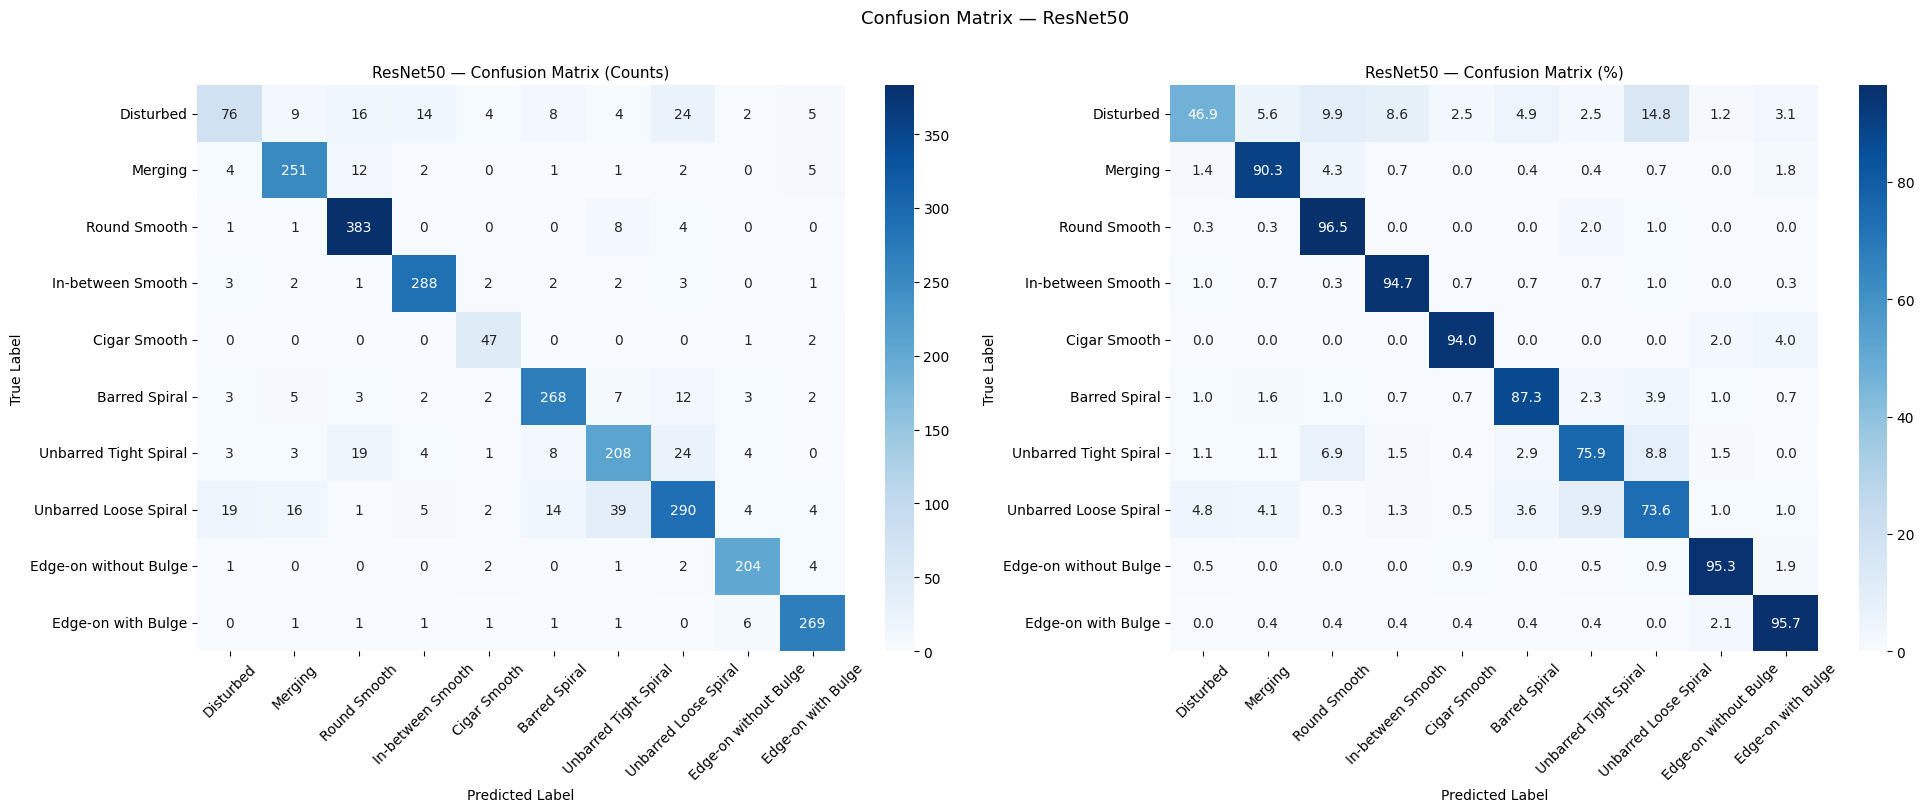


ResNet50 — Per-class accuracy:
  Disturbed                     : 46.9%
  Merging                       : 90.3%
  Round Smooth                  : 96.5%
  In-between Smooth             : 94.7%
  Cigar Smooth                  : 94.0%
  Barred Spiral                 : 87.3%
  Unbarred Tight Spiral         : 75.9%
  Unbarred Loose Spiral         : 73.6%
  Edge-on without Bulge         : 95.3%
  Edge-on with Bulge            : 95.7%



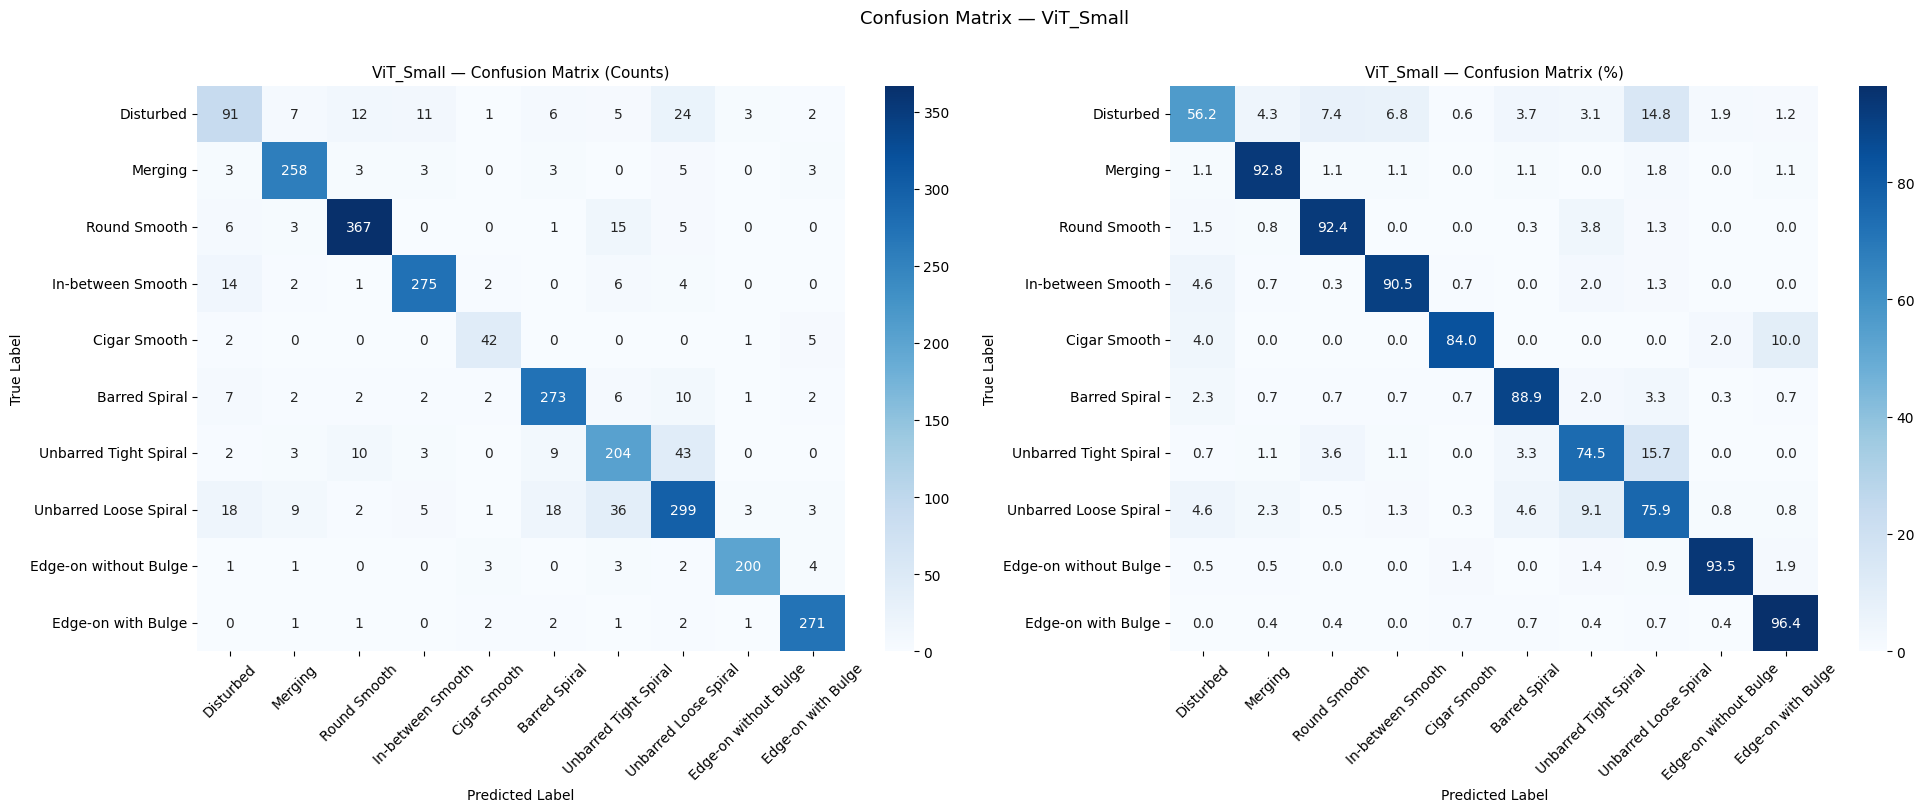


ViT_Small — Per-class accuracy:
  Disturbed                     : 56.2%
  Merging                       : 92.8%
  Round Smooth                  : 92.4%
  In-between Smooth             : 90.5%
  Cigar Smooth                  : 84.0%
  Barred Spiral                 : 88.9%
  Unbarred Tight Spiral         : 74.5%
  Unbarred Loose Spiral         : 75.9%
  Edge-on without Bulge         : 93.5%
  Edge-on with Bulge            : 96.4%



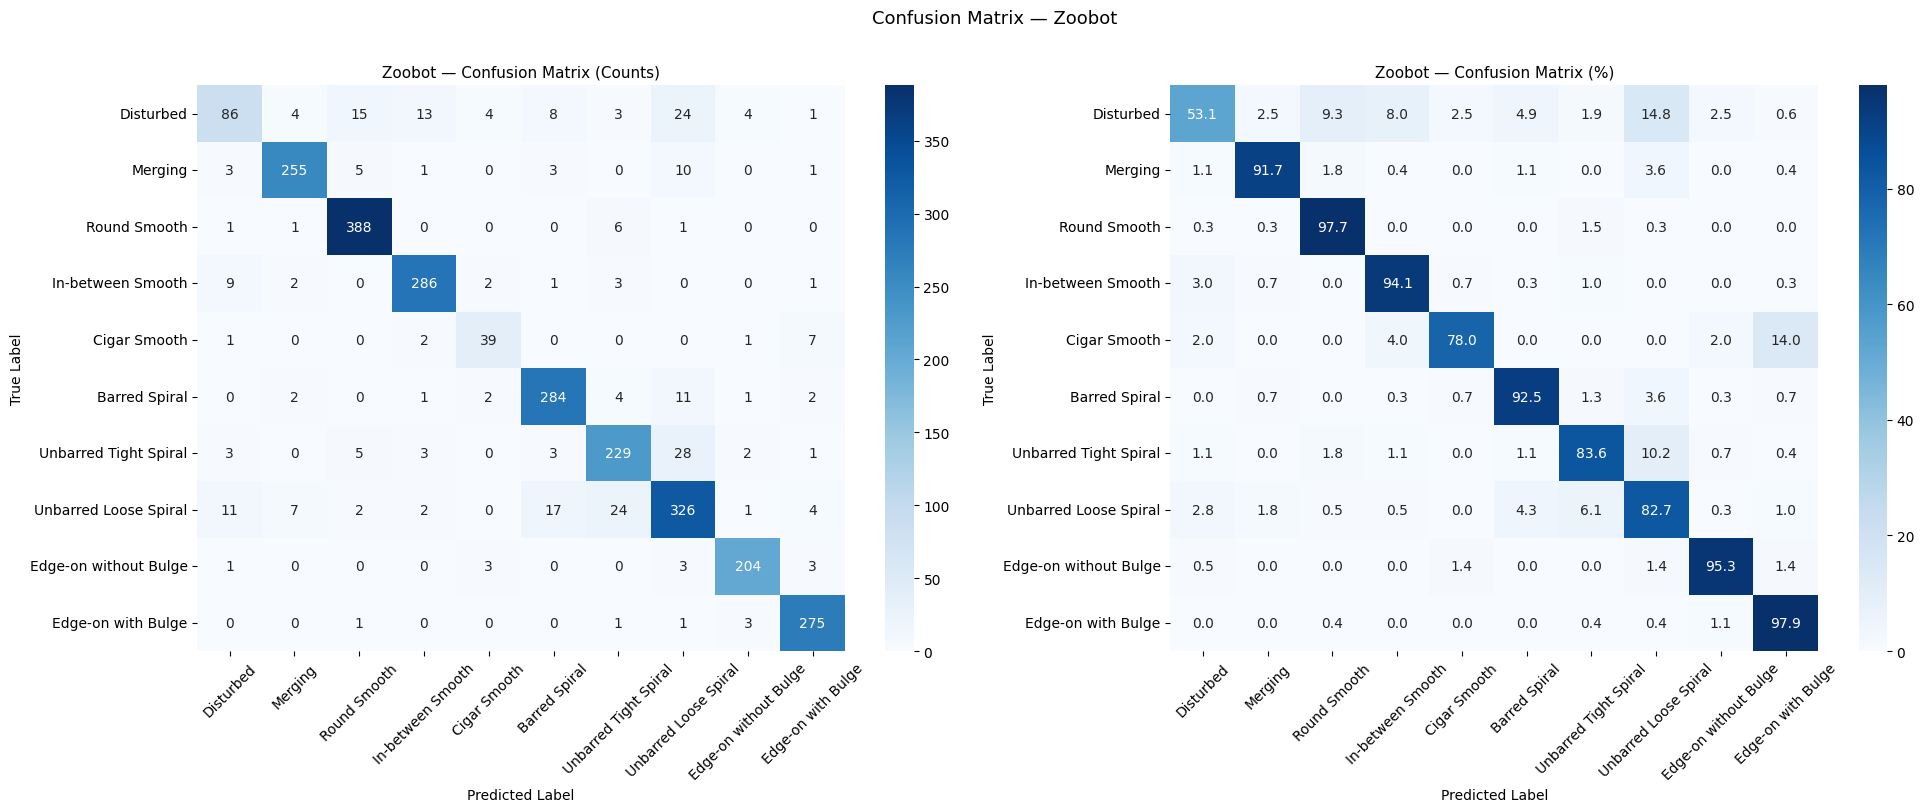


Zoobot — Per-class accuracy:
  Disturbed                     : 53.1%
  Merging                       : 91.7%
  Round Smooth                  : 97.7%
  In-between Smooth             : 94.1%
  Cigar Smooth                  : 78.0%
  Barred Spiral                 : 92.5%
  Unbarred Tight Spiral         : 83.6%
  Unbarred Loose Spiral         : 82.7%
  Edge-on without Bulge         : 95.3%
  Edge-on with Bulge            : 97.9%

Saved: confmat_ResNet50.png
Saved: confmat_ViT_Small.png
Saved: confmat_Zoobot.png


In [ ]:
#Step 1: Confusion Matrices

# 10x10 grid showing where each model makes mistakes
# Diagonal = correct, off-diagonal = errors


import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import shutil

def plot_confusion_matrix(model, model_name, loader=None):
    if loader is None:
        loader = test_loader

    model.eval()
    all_preds, all_true = [], []

    with torch.no_grad():
        for imgs, lbls in loader:
            preds = model(imgs.to(device)).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_true.extend(lbls.numpy())

    cm = confusion_matrix(all_true, all_preds)

    # Normalize to percentages
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES,
                ax=axes[0], cbar=True)
    axes[0].set_title(f'{model_name} — Confusion Matrix (Counts)',
                      fontsize=11)
    axes[0].set_ylabel('True Label', fontsize=10)
    axes[0].set_xlabel('Predicted Label', fontsize=10)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].tick_params(axis='y', rotation=0)

    # Normalized percentages
    sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES,
                ax=axes[1], cbar=True)
    axes[1].set_title(f'{model_name} — Confusion Matrix (%)',
                      fontsize=11)
    axes[1].set_ylabel('True Label', fontsize=10)
    axes[1].set_xlabel('Predicted Label', fontsize=10)
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].tick_params(axis='y', rotation=0)

    plt.suptitle(f'Confusion Matrix — {model_name}',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(f'confmat_{model_name}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    # Print per-class accuracy
    print(f"\n{model_name} — Per-class accuracy:")
    for i, name in enumerate(CLASS_NAMES):
        if cm[i].sum() > 0:
            acc = cm[i, i] / cm[i].sum() * 100
            print(f"  {name:<30}: {acc:.1f}%")
    print()


# Generate for all three models
plot_confusion_matrix(resnet,       'ResNet50')
plot_confusion_matrix(vit,          'ViT_Small')
plot_confusion_matrix(zoobot_model, 'Zoobot')

# Save to Drive
for fname in ['confmat_ResNet50.png',
              'confmat_ViT_Small.png',
              'confmat_Zoobot.png']:
    shutil.copy(fname, f'/content/drive/MyDrive/{fname}')
    print(f"Saved: {fname}")

In [ ]:
#Step 2: Grad-CAM Heatmaps

# Shows WHICH PIXELS the model focused on for each prediction
# Verifies model looks at galaxy structure not background


# ============================================================
# PHASE G — GRAD-CAM FIXED FOR ALL THREE MODELS
# ResNet: standard GradCAM (works with CNN)
# ViT: GradCAM++ with reshape transform (works with transformers)
# Zoobot: standard GradCAM (EfficientNet is a CNN)
# ============================================================

from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import numpy as np


def reshape_transform_vit(tensor, height=14, width=14):
    """
    ViT outputs sequence of patch tokens.
    This reshapes them back to 2D spatial format for GradCAM.
    height=14, width=14 because 224/16 = 14 patches per side
    """
    # Remove the class token (first token)
    result = tensor[:, 1:, :]
    # Reshape to (batch, height, width, channels)
    result = result.reshape(tensor.size(0), height, width, tensor.size(2))
    # Transpose to (batch, channels, height, width)
    result = result.transpose(2, 3).transpose(1, 2)
    return result


def generate_gradcam_fixed(model, target_layer, model_name,
                            n_images=8, dataset=None,
                            is_vit=False):
    if dataset is None:
        dataset = test_ds

    # Use appropriate CAM method
    if is_vit:
        cam = GradCAMPlusPlus(
            model=model,
            target_layers=[target_layer],
            reshape_transform=reshape_transform_vit
        )
    else:
        cam = GradCAM(
            model=model,
            target_layers=[target_layer]
        )

    # Pick one image per class
    sample_indices = []
    for class_id in range(min(n_images, NUM_CLASSES)):
        for j in range(len(dataset)):
            _, lbl = dataset[j]
            if lbl == class_id:
                sample_indices.append(j)
                break
    while len(sample_indices) < n_images:
        sample_indices.append(len(sample_indices) * 50)

    fig, axes = plt.subplots(2, n_images, figsize=(20, 5))

    for plot_i, ds_idx in enumerate(sample_indices[:n_images]):
        img_tensor, true_label = dataset[ds_idx]
        input_t = img_tensor.unsqueeze(0).to(device)

        # Prediction
        model.eval()
        with torch.no_grad():
            output     = model(input_t)
            pred_label = output.argmax(1).item()
            confidence = torch.softmax(output, 1).max().item()

        # Grad-CAM
        try:
            targets = [ClassifierOutputTarget(pred_label)]
            cam_map = cam(input_tensor=input_t,
                          targets=targets)[0]
        except Exception as e:
            print(f"  CAM failed for image {plot_i}: {e}")
            cam_map = np.zeros((224, 224))

        # Display image
        img_show = img_tensor.permute(1, 2, 0).numpy()
        img_show = ((img_show - img_show.min()) /ve/{fname})
    print(f"Saved to Drive: {fname}")

Generating Grad-CAM for ResNet50


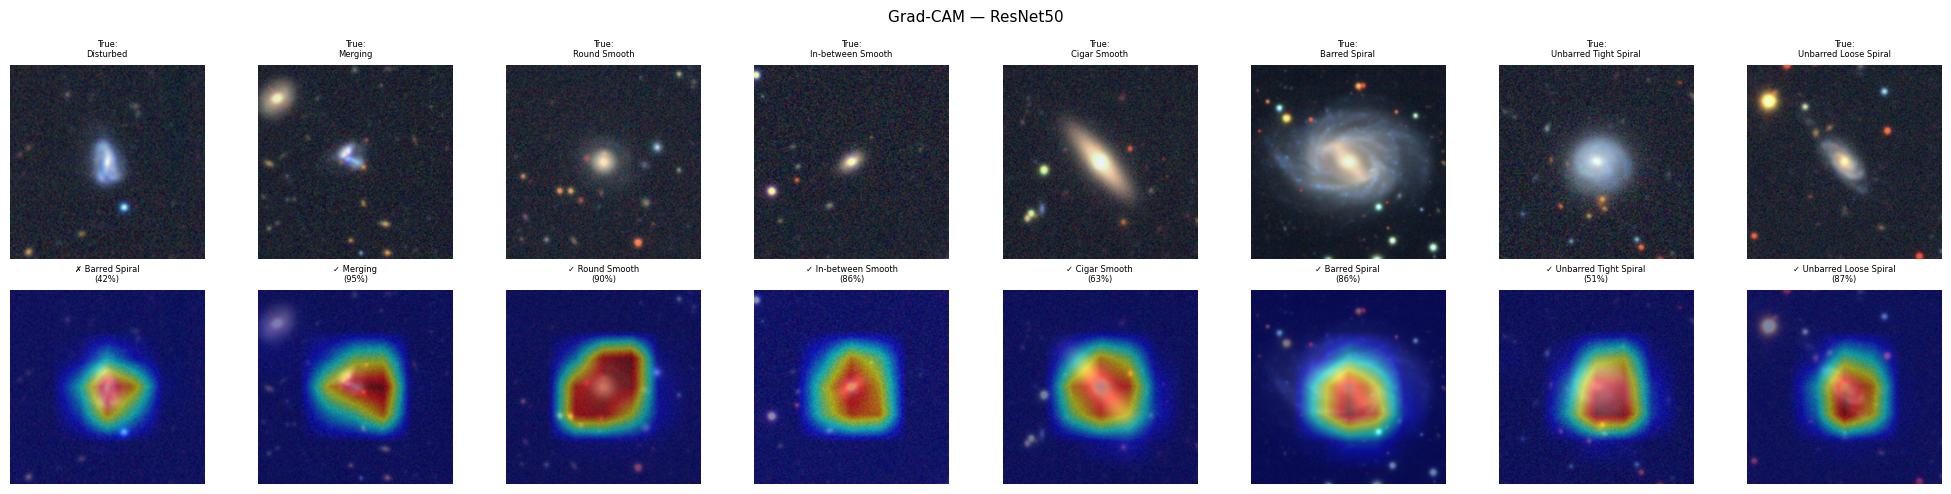

Saved: gradcam_ResNet50.png

Generating Grad-CAM for ViT_Small


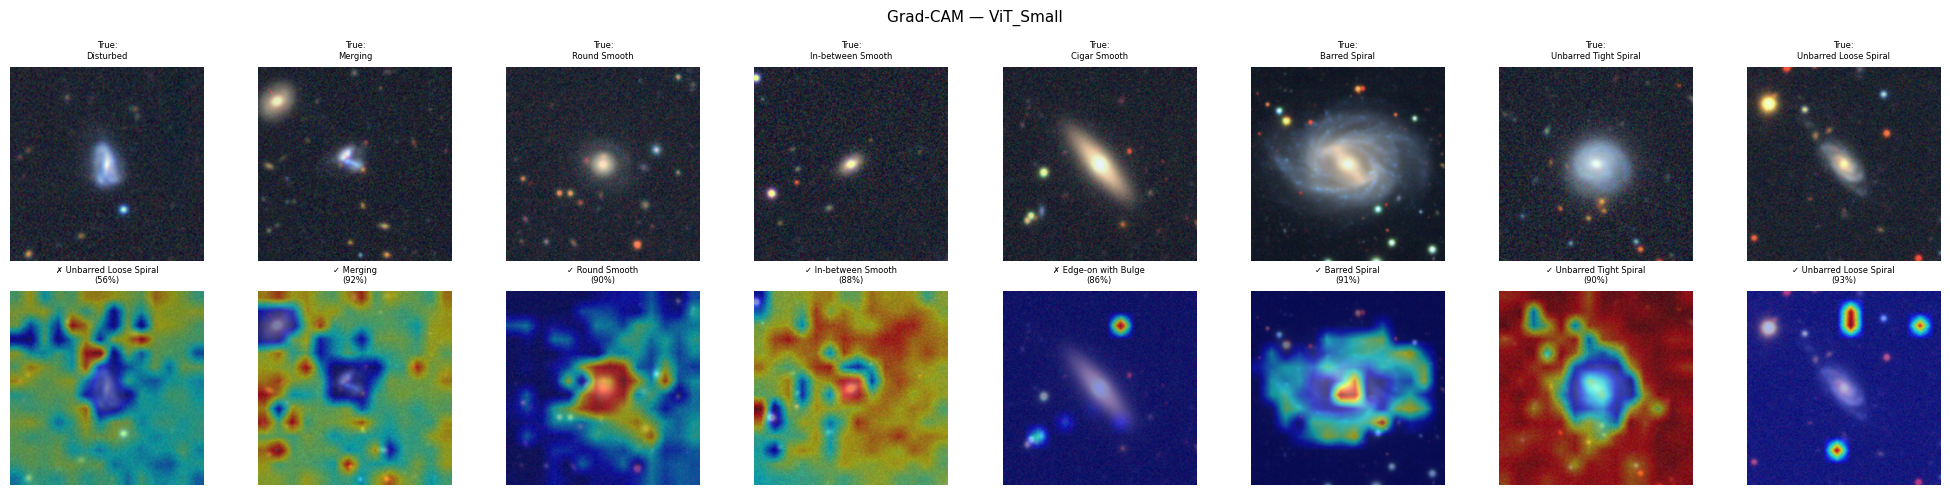

Saved: gradcam_ViT_Small.png

Generating Grad-CAM for Zoobot


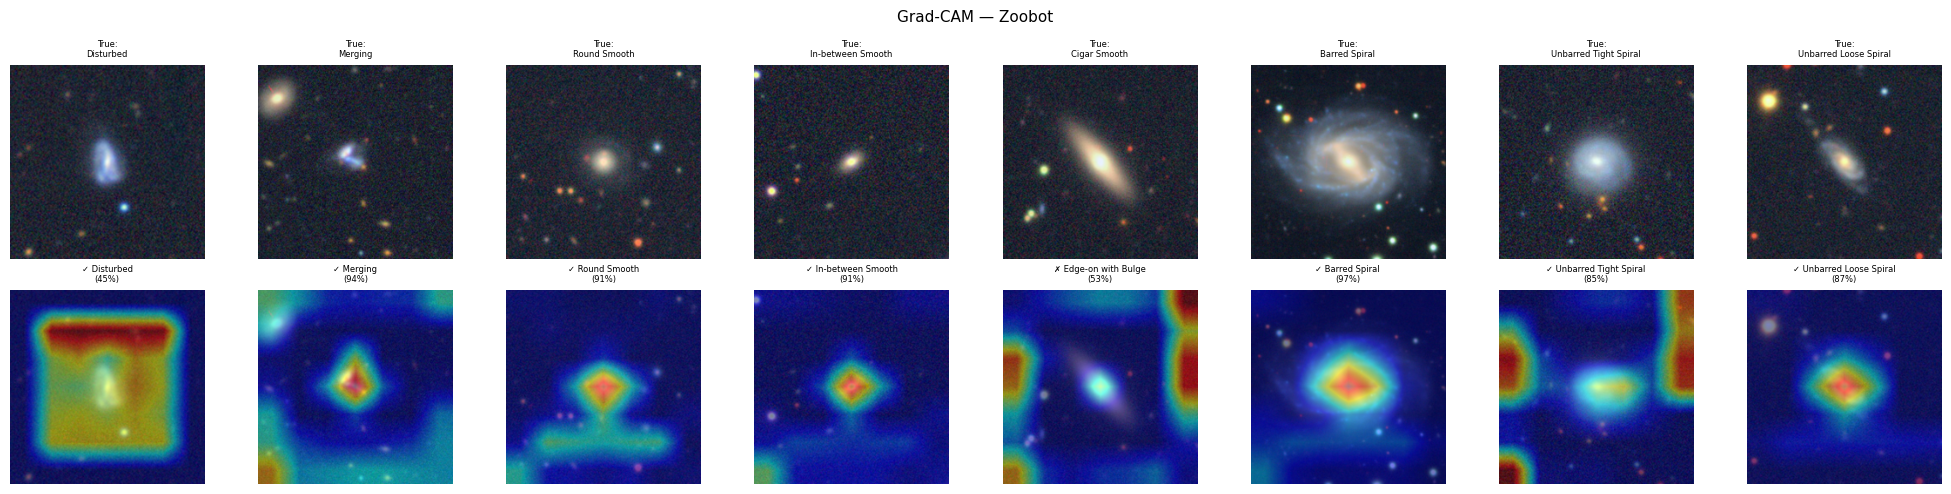

Saved: gradcam_Zoobot.png
Saved to Drive: gradcam_ResNet50.png
Saved to Drive: gradcam_ViT_Small.png
Saved to Drive: gradcam_Zoobot.png

All Grad-CAM figures complete.


In [ ]:
#Step 2: Grad-CAM fixed for all three models

# ResNet: standard GradCAM (works with CNN)
# ViT: GradCAM++ with reshape transform (works with transformers)
# Zoobot: standard GradCAM (EfficientNet is a CNN)


from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import numpy as np


def reshape_transform_vit(tensor, height=14, width=14):
    """
    ViT outputs sequence of patch tokens.
    This reshapes them back to 2D spatial format for GradCAM.
    height=14, width=14 because 224/16 = 14 patches per side
    """
    # Remove the class token (first token)
    result = tensor[:, 1:, :]
    # Reshape to (batch, height, width, channels)
    result = result.reshape(tensor.size(0), height, width, tensor.size(2))
    # Transpose to (batch, channels, height, width)
    result = result.transpose(2, 3).transpose(1, 2)
    return result


def generate_gradcam_fixed(model, target_layer, model_name,
                            n_images=8, dataset=None,
                            is_vit=False):
    if dataset is None:
        dataset = test_ds

    # Use appropriate CAM method
    if is_vit:
        cam = GradCAMPlusPlus(
            model=model,
            target_layers=[target_layer],
            reshape_transform=reshape_transform_vit
        )
    else:
        cam = GradCAM(
            model=model,
            target_layers=[target_layer]
        )

    # Pick one image per class
    sample_indices = []
    for class_id in range(min(n_images, NUM_CLASSES)):
        for j in range(len(dataset)):
            _, lbl = dataset[j]
            if lbl == class_id:
                sample_indices.append(j)
                break
    while len(sample_indices) < n_images:
        sample_indices.append(len(sample_indices) * 50)

    fig, axes = plt.subplots(2, n_images, figsize=(20, 5))

    for plot_i, ds_idx in enumerate(sample_indices[:n_images]):
        img_tensor, true_label = dataset[ds_idx]
        input_t = img_tensor.unsqueeze(0).to(device)

        # Prediction
        model.eval()
        with torch.no_grad():
            output     = model(input_t)
            pred_label = output.argmax(1).item()
            confidence = torch.softmax(output, 1).max().item()

        # Grad-CAM
        try:
            targets = [ClassifierOutputTarget(pred_label)]
            cam_map = cam(input_tensor=input_t,
                          targets=targets)[0]
        except Exception as e:
            print(f"  CAM failed for image {plot_i}: {e}")
            cam_map = np.zeros((224, 224))

        # Display image
        img_show = img_tensor.permute(1, 2, 0).numpy()
        img_show = ((img_show - img_show.min()) /
                    (img_show.max() - img_show.min() + 1e-8))
        img_show = img_show.astype(np.float32)

        vis     = show_cam_on_image(img_show, cam_map, use_rgb=True)
        correct = "✓" if pred_label == true_label else "✗"

        axes[0, plot_i].imshow(img_show)
        axes[0, plot_i].set_title(
            f"True:\n{CLASS_NAMES[true_label]}", fontsize=6)
        axes[0, plot_i].axis('off')

        axes[1, plot_i].imshow(vis)
        axes[1, plot_i].set_title(
            f"{correct} {CLASS_NAMES[pred_label]}\n"
            f"({confidence*100:.0f}%)", fontsize=6)
        axes[1, plot_i].axis('off')

    axes[0, 0].set_ylabel('Original', fontsize=9)
    axes[1, 0].set_ylabel('Grad-CAM', fontsize=9)
    plt.suptitle(f'Grad-CAM — {model_name}', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'gradcam_{model_name}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: gradcam_{model_name}.png")


#ResNet-50 — standard GradCAM
print("Generating Grad-CAM for ResNet50")
resnet_target = resnet.layer4[-1]
generate_gradcam_fixed(resnet, resnet_target,
                       'ResNet50', is_vit=False)

#ViT-Small — GradCAM++ with reshape
print("\nGenerating Grad-CAM for ViT_Small")
vit_target = vit.blocks[-1].norm1
generate_gradcam_fixed(vit, vit_target,
                       'ViT_Small', is_vit=True)

#Zoobot — standard GradCAM (EfficientNet is CNN)
print("\nGenerating Grad-CAM for Zoobot")
zoobot_target = zoobot_model.encoder.blocks[-1]
generate_gradcam_fixed(zoobot_model, zoobot_target,
                       'Zoobot', is_vit=False)

# Save all to Drive
import shutil
for fname in ['gradcam_ResNet50.png',
              'gradcam_ViT_Small.png',
              'gradcam_Zoobot.png']:
    shutil.copy(fname, f'/content/drive/MyDrive/{fname}')
    print(f"Saved to Drive: {fname}")

print("\nAll Grad-CAM figures complete.")

Top row — original galaxy images, one per class (Disturbed, Merging, Round Smooth, In-between Smooth, Cigar Smooth, Barred Spiral, Unbarred Tight Spiral, Unbarred Loose Spiral)
Bottom row — same images with heatmap overlay showing where the model looked. Colors mean:

    Red/Yellow = model focused heavily here (most important pixels)
    Blue/Green = model ignored these areas

In [ ]:
# ============================================================
# PER-CLASS F1 + PER-CLASS ACCURACY TABLES
# ============================================================

from sklearn.metrics import f1_score, confusion_matrix
import pandas as pd
import numpy as np
import torch


def evaluate_per_class(model, model_name):
    """
    Run the model once on the test set and calculate:
      1. Per-class F1
      2. Per-class accuracy (same as per-class recall)
      3. Confusion matrix

    The exact same predictions are used for all metrics.
    """

    model.eval()

    all_preds = []
    all_true = []

    with torch.no_grad():

        for imgs, lbls in test_loader:

            imgs = imgs.to(device)

            outputs = model(imgs)

            preds = outputs.argmax(1).cpu().numpy()
            true_labels = lbls.numpy()

            all_preds.extend(preds)
            all_true.extend(true_labels)

    all_preds = np.asarray(all_preds)
    all_true = np.asarray(all_true)

    # --------------------------------------------------------
    # Confusion matrix
    # --------------------------------------------------------

    cm = confusion_matrix(
        all_true,
        all_preds,
        labels=np.arange(len(CLASS_NAMES))
    )

    # --------------------------------------------------------
    # Per-class F1
    # --------------------------------------------------------

    f1_per_class = f1_score(
        all_true,
        all_preds,
        labels=np.arange(len(CLASS_NAMES)),
        average=None,
        zero_division=0
    )

    # --------------------------------------------------------
    # Per-class accuracy
    #
    # For each true class:
    #
    # correct predictions
    # --------------------
    # total true examples
    #
    # This is technically per-class recall.
    # --------------------------------------------------------

    row_totals = cm.sum(axis=1)

    per_class_accuracy = np.divide(
        np.diag(cm),
        row_totals,
        out=np.zeros(len(CLASS_NAMES), dtype=float),
        where=row_totals != 0
    )

    print(f"\n{model_name}")
    print("-" * 60)
    print("Test images :", len(all_true))
    print("Correct     :", np.sum(all_true == all_preds))
    print("Accuracy    :", np.mean(all_true == all_preds) * 100)

    return {
        "f1": f1_per_class,
        "accuracy": per_class_accuracy,
        "confusion_matrix": cm,
        "y_true": all_true,
        "y_pred": all_preds
    }


# ============================================================
# RUN ALL THREE MODELS
# ============================================================

print("=" * 70)
print("CALCULATING PER-CLASS F1 AND ACCURACY")
print("=" * 70)

resnet_results = evaluate_per_class(
    resnet,
    "ResNet-50"
)

vit_results = evaluate_per_class(
    vit,
    "ViT-Small"
)

zoobot_results = evaluate_per_class(
    zoobot_model,
    "Zoobot"
)


# ============================================================
# EXTRACT METRICS
# ============================================================

resnet_f1 = resnet_results["f1"]
vit_f1    = vit_results["f1"]
zoo_f1    = zoobot_results["f1"]

resnet_acc = resnet_results["accuracy"]
vit_acc    = vit_results["accuracy"]
zoo_acc    = zoobot_results["accuracy"]


# ============================================================
# TABLE 3 — PER-CLASS F1
# ============================================================

df_f1 = pd.DataFrame({

    "Class": CLASS_NAMES,

    "ResNet50": [
        round(x * 100, 1)
        for x in resnet_f1
    ],

    "ViT_Small": [
        round(x * 100, 1)
        for x in vit_f1
    ],

    "Zoobot": [
        round(x * 100, 1)
        for x in zoo_f1
    ]
})


print("\n")
print("=" * 70)
print("TABLE 3 — PER-CLASS F1 SCORES (%)")
print("=" * 70)

print(
    df_f1.to_string(index=False)
)


# ============================================================
# TABLE 4 — PER-CLASS ACCURACY
# ============================================================

df_accuracy = pd.DataFrame({

    "Class": CLASS_NAMES,

    "ResNet50": [
        round(x * 100, 1)
        for x in resnet_acc
    ],

    "ViT_Small": [
        round(x * 100, 1)
        for x in vit_acc
    ],

    "Zoobot": [
        round(x * 100, 1)
        for x in zoo_acc
    ]
})


print("\n")
print("=" * 70)
print("TABLE 4 — PER-CLASS ACCURACY (%)")
print("=" * 70)

print(
    df_accuracy.to_string(index=False)
)


# ============================================================
# SAVE TABLE 3
# ============================================================

f1_path = "/content/drive/MyDrive/per_class_f1.csv"

df_f1.to_csv(
    f1_path,
    index=False
)

print("\n✓ Saved:", f1_path)


# ============================================================
# SAVE TABLE 4
# ============================================================

accuracy_path = (
    "/content/drive/MyDrive/"
    "Table_4_Per_Class_Accuracy.csv"
)

df_accuracy.to_csv(
    accuracy_path,
    index=False
)

print("✓ Saved:", accuracy_path)


# ============================================================
# SAVE THE THREE CONFUSION MATRICES
# ============================================================

cm_resnet50 = resnet_results["confusion_matrix"]
cm_vit_small = vit_results["confusion_matrix"]
cm_zoobot = zoobot_results["confusion_matrix"]


print("\n")
print("=" * 70)
print("CONFUSION MATRICES")
print("=" * 70)

print("\nResNet-50:")
print(cm_resnet50)

print("\nViT-Small:")
print(cm_vit_small)

print("\nZoobot:")
print(cm_zoobot)


# ============================================================
# SANITY CHECK
# ============================================================

print("\n")
print("=" * 70)
print("SANITY CHECK — TABLE 4")
print("=" * 70)

for i, class_name in enumerate(CLASS_NAMES):

    print(
        f"{class_name:<30} "
        f"ResNet={resnet_acc[i]*100:5.1f}%   "
        f"ViT={vit_acc[i]*100:5.1f}%   "
        f"Zoobot={zoo_acc[i]*100:5.1f}%"
    )

print("=" * 70)
print("✓ F1 and per-class accuracy calculated from the same predictions.")
print("✓ Table 3 and Table 4 generated.")
print("✓ Confusion matrices retained for verification.")
print("=" * 70)

CALCULATING PER-CLASS F1 AND ACCURACY

ResNet-50
------------------------------------------------------------
Test images : 2661
Correct     : 2284
Accuracy    : 85.83239383690342

ViT-Small
------------------------------------------------------------
Test images : 2661
Correct     : 2280
Accuracy    : 85.68207440811724

Zoobot
------------------------------------------------------------
Test images : 2661
Correct     : 2372
Accuracy    : 89.13942127019916


TABLE 3 — PER-CLASS F1 SCORES (%)
                Class  ResNet50  ViT_Small  Zoobot
            Disturbed      55.9       59.5    62.1
              Merging      88.7       91.5    92.9
         Round Smooth      92.0       92.3    95.4
    In-between Smooth      92.9       91.2    93.5
         Cigar Smooth      84.7       81.6    78.0
        Barred Spiral      88.0       88.2    91.2
Unbarred Tight Spiral      76.3       74.2    84.2
Unbarred Loose Spiral      76.8       75.9    81.7
Edge-on without Bulge      93.2       94.6  

In [ ]:
#EFFICIENCY TABLE
# Parameters + inference speed comparison


import time
import pandas as pd

def measure_inference_speed(model, n_runs=100):
    """Measures inference time per image in milliseconds"""
    model.eval()
    dummy = torch.randn(1, 3, 224, 224).to(device)

    # Warmup
    with torch.no_grad():
        for _ in range(10):
            model(dummy)

    # Measure
    start = time.time()
    with torch.no_grad():
        for _ in range(n_runs):
            model(dummy)
    elapsed = (time.time() - start) / n_runs * 1000
    return round(elapsed, 2)


efficiency_data = []
for name, model in [
    ('ResNet50',  resnet),
    ('ViT_Small', vit),
    ('Zoobot',    zoobot_model)
]:
    params = sum(
        p.numel() for p in model.parameters()) / 1e6
    speed  = measure_inference_speed(model)

    efficiency_data.append({
        'Model':            name,
        'Parameters (M)':   round(params, 2),
        'Inference (ms)':   speed,
        'Accuracy (%)':     {
            'ResNet50':  85.83,
            'ViT_Small': 85.68,
            'Zoobot':    89.14
        }[name]
    })
    print(f"{name}: {params:.2f}M params, {speed}ms/image")

df_eff = pd.DataFrame(efficiency_data)
print("\nEFFICIENCY TABLE")
print("="*55)
print(df_eff.to_string(index=False))
print("="*55)

df_eff.to_csv('/content/drive/MyDrive/efficiency_table.csv',
               index=False)
print("✓ Saved: efficiency_table.csv")

ResNet50: 23.53M params, 7.98ms/image
ViT_Small: 21.67M params, 7.78ms/image
Zoobot: 4.34M params, 10.93ms/image

EFFICIENCY TABLE
    Model  Parameters (M)  Inference (ms)  Accuracy (%)
 ResNet50           23.53            7.98         85.83
ViT_Small           21.67            7.78         85.68
   Zoobot            4.34           10.93         89.14
✓ Saved: efficiency_table.csv


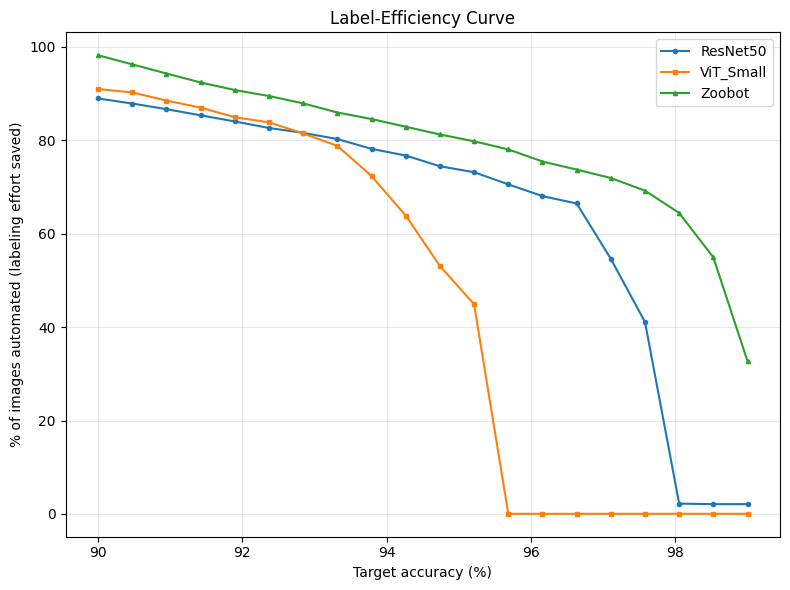

Saved: label_efficiency_curve.png
ResNet50: at 95% accuracy target, 73.1% of labeling can be automated
ViT_Small: at 95% accuracy target, 44.9% of labeling can be automated
Zoobot: at 95% accuracy target, 79.7% of labeling can be automated


In [ ]:
#Step 2b: Label-Efficiency Curve
# For a range of target accuracy thresholds, find the maximum coverage
# (fraction of images automated) that still hits that accuracy.
# The remainder = fraction of images that still need expert labeling.

def label_efficiency_curve(uncertainty, true_labels, mean_preds, accuracy_targets):
    preds = mean_preds.argmax(1).numpy()
    correct = (preds == true_labels)
    unc = uncertainty.numpy()

    order = np.argsort(unc)          # most confident first
    sorted_correct = correct[order]
    n = len(sorted_correct)

    # cumulative accuracy as we keep more and more images (sorted by confidence)
    cum_acc = np.cumsum(sorted_correct) / (np.arange(n) + 1)

    coverage_at_target = []
    for target in accuracy_targets:
        # find the largest coverage where cumulative accuracy still >= target
        valid = np.where(cum_acc >= target)[0]
        cov = (valid.max() + 1) / n if len(valid) > 0 else 0.0
        coverage_at_target.append(cov)

    labels_saved = [c * 100 for c in coverage_at_target]  # % of dataset auto-labeled
    return np.array(accuracy_targets), np.array(labels_saved)

accuracy_targets = np.linspace(0.90, 0.99, 20)

targets_resnet, saved_resnet = label_efficiency_curve(resnet_unc, resnet_true, resnet_mean, accuracy_targets)
targets_vit, saved_vit       = label_efficiency_curve(vit_unc, vit_true, vit_mean, accuracy_targets)
targets_zoo, saved_zoo       = label_efficiency_curve(zoo_unc, zoo_true, zoo_mean, accuracy_targets)

plt.figure(figsize=(8, 6))
plt.plot(targets_resnet*100, saved_resnet, label='ResNet50', marker='o', markersize=3)
plt.plot(targets_vit*100, saved_vit, label='ViT_Small', marker='s', markersize=3)
plt.plot(targets_zoo*100, saved_zoo, label='Zoobot', marker='^', markersize=3)
plt.xlabel('Target accuracy (%)')
plt.ylabel('% of images automated (labeling effort saved)')
plt.title('Label-Efficiency Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('label_efficiency_curve.png', dpi=120)
plt.show()
print("Saved: label_efficiency_curve.png")

# Concrete headline number for the paper
for name, targets, saved in [('ResNet50', targets_resnet, saved_resnet),
                               ('ViT_Small', targets_vit, saved_vit),
                               ('Zoobot', targets_zoo, saved_zoo)]:
    idx_95 = np.argmin(np.abs(targets - 0.95))
    print(f"{name}: at 95% accuracy target, {saved[idx_95]:.1f}% of labeling can be automated")

In [ ]:
# ============================================================
# TABLE 4 — PER-CLASS ACCURACY
# ============================================================
#
# Per-class accuracy:
#     diagonal of confusion matrix / total samples in true class
#
# This table contains:
#     10 Galaxy10 classes × 3 models
#
# Models:
#     ResNet-50
#     ViT-Small
#     Zoobot
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Galaxy10 class names
# ------------------------------------------------------------

CLASS_NAMES = [
    "Disturbed",
    "Merging",
    "Round Smooth",
    "In-between Smooth",
    "Cigar Smooth",
    "Barred Spiral",
    "Unbarred Tight Spiral",
    "Unbarred Loose Spiral",
    "Edge-on without Bulge",
    "Edge-on with Bulge"
]


# ------------------------------------------------------------
# 2. Helper function
# ------------------------------------------------------------

def per_class_accuracy_from_cm(cm):
    """
    Calculate per-class accuracy from a confusion matrix.

    Rows    = true classes
    Columns = predicted classes

    Per-class accuracy =
        correctly classified samples / total true samples
    """

    cm = np.asarray(cm, dtype=float)

    if cm.shape != (10, 10):
        raise ValueError(
            f"Expected a 10×10 confusion matrix, "
            f"but received shape {cm.shape}"
        )

    row_totals = cm.sum(axis=1)
    diagonal = np.diag(cm)

    accuracy = np.divide(
        diagonal,
        row_totals,
        out=np.zeros_like(diagonal, dtype=float),
        where=row_totals != 0
    )

    return accuracy


# ------------------------------------------------------------
# 3. IMPORTANT:
#    Put your three VERIFIED confusion matrices here
# ------------------------------------------------------------
#
# Replace the three variable names below ONLY if your notebook
# uses different names.
#
# They must be the SAME confusion matrices used to create
# Figure 3.1, Figure 3.2 and Figure 3.3.
#
# Expected shape for each:
#     (10, 10)
#
# Example:
#     cm_resnet50 = confusion_matrix(...)
#     cm_vit_small = confusion_matrix(...)
#     cm_zoobot = confusion_matrix(...)
# ------------------------------------------------------------

required_cm = [
    "cm_resnet50",
    "cm_vit_small",
    "cm_zoobot"
]

missing_cm = [
    x for x in required_cm
    if x not in globals()
]

if missing_cm:
    raise RuntimeError(
        "\nMissing confusion-matrix variables:\n"
        + "\n".join(f"  - {x}" for x in missing_cm)
        + "\n\nUse the exact confusion matrices that were used "
          "to generate Figures 3.1–3.3."
    )


# ------------------------------------------------------------
# 4. Calculate per-class accuracy
# ------------------------------------------------------------

acc_resnet50 = per_class_accuracy_from_cm(cm_resnet50)
acc_vit_small = per_class_accuracy_from_cm(cm_vit_small)
acc_zoobot = per_class_accuracy_from_cm(cm_zoobot)


# ------------------------------------------------------------
# 5. Create Table 4
# ------------------------------------------------------------

table_4 = pd.DataFrame({
    "Class": CLASS_NAMES,
    "ResNet-50": acc_resnet50 * 100,
    "ViT-Small": acc_vit_small * 100,
    "Zoobot": acc_zoobot * 100
})


# ------------------------------------------------------------
# 6. Round for manuscript presentation
# ------------------------------------------------------------

table_4_display = table_4.copy()

for model in ["ResNet-50", "ViT-Small", "Zoobot"]:
    table_4_display[model] = (
        table_4_display[model]
        .round(2)
    )


# ------------------------------------------------------------
# 7. Display
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("TABLE 4 — PER-CLASS ACCURACY (%)")
print("=" * 75)

print(
    table_4_display.to_string(
        index=False
    )
)

print("=" * 75)


# ------------------------------------------------------------
# 8. Save CSV
# ------------------------------------------------------------

output_file = "Table_4_Per_Class_Accuracy.csv"

table_4_display.to_csv(
    output_file,
    index=False
)

print(f"\n✓ Table saved as: {output_file}")


# ------------------------------------------------------------
# 9. Sanity checks
# ------------------------------------------------------------

print("\nSanity checks:")

print(
    "ResNet-50 classes:",
    len(acc_resnet50)
)

print(
    "ViT-Small classes:",
    len(acc_vit_small)
)

print(
    "Zoobot classes:",
    len(acc_zoobot)
)

assert len(acc_resnet50) == 10
assert len(acc_vit_small) == 10
assert len(acc_zoobot) == 10

assert np.all(acc_resnet50 >= 0)
assert np.all(acc_resnet50 <= 1)

assert np.all(acc_vit_small >= 0)
assert np.all(acc_vit_small <= 1)

assert np.all(acc_zoobot >= 0)
assert np.all(acc_zoobot <= 1)

print("✓ All 3 models have exactly 10 class accuracies.")
print("✓ All values are between 0% and 100%.")
print("✓ Table 4 generation complete.")

RuntimeError: 
Missing confusion-matrix variables:
  - cm_resnet50
  - cm_vit_small
  - cm_zoobot

Use the exact confusion matrices that were used to generate Figures 3.1–3.3.